
<div style="background: linear-gradient(135deg, #1d2b1f 0%, #2b2118 55%, #1d1810 100%); padding: 38px 34px; border-radius: 6px; border: 1px solid #a8792a; box-shadow: 0 0 0 6px #f4ecd8, 0 0 0 7px #a8792a;">
<h1 style="color:#e8d9ad; font-family: Georgia, 'Palatino Linotype', serif; text-align:center; letter-spacing:2px; margin:0; font-size:2.1em;">&#9973; THE LONG DEFEAT &#9973;</h1>
<p style="color:#c9a35f; text-align:center; font-family: Georgia, serif; font-style:italic; margin:10px 0 0 0; font-size:1.15em;">A Demographic and Dynastic Analysis of the Realms of the D&uacute;nedain</p>
<p style="color:#8a9a8a; text-align:center; font-family: Georgia, serif; margin:14px 0 0 0; font-size:0.85em;">N&uacute;menor &middot; Arnor &middot; Arthedain &middot; the Chieftains &middot; Gondor &middot; the Ruling Stewards &middot; (with Rohan for comparison)</p>
</div>

*"Yet even as the Kings of Men fell into darkness... and the Dark Lord gathered all the Rings to him... one Ring to rule them all."* Appendix A tells us who reigned and when. It does not tell us the averages. That part we have to compute ourselves.



## What this actually is

Every number below is **derived**, not invented. The raw inputs are birth years, accession years, and death years as recorded in Tolkien's own texts. Everything else &mdash; averages, medians, standard deviations, percentages, "longest reign," "youngest ruler" &mdash; is computed from those inputs in this notebook, the same way you'd treat any historical demographic dataset.

**Primary sources used, and how they were used:**

| Source | Used for |
|---|---|
| *The Lord of the Rings*, Appendix A & B | Kings of Arnor/Arthedain, Chieftains, Kings of Gondor, Ruling Stewards &mdash; birth/reign/death years, succession notes |
| *The Silmarillion* | Founding of N&uacute;menor, the Downfall, background on the Line of Elros |
| *Unfinished Tales* | The full table of N&uacute;menor's 25 monarchs ("The Line of Elros"), with reign and lifespan years |
| *The Peoples of Middle-earth* (HoMe XII) | Steward birth years (not all given in the published Appendix A text); a couple of noted alternate/draft king-names |
| Tolkien Gateway / secondary wikis | Used only as a fast index into the primary citations above &mdash; cross-checked against at least one other source before being encoded here, and one figure (Aldamir's cause of death) was specifically re-verified after an initial low-confidence guess |

**Where the data runs out, we say so.** Appendix B gives full birth-to-death dates for the Kings of Arnor, Arthedain, and Gondor, and for the Ruling Stewards &mdash; but for 11 of the 16 Chieftains of the D&uacute;nedain, and about half of the Kings of Rohan, only the *year they took power* survives, not their birth year. Rather than estimate a plausible-looking birth year to fill the gap, those cells are left blank and excluded from lifespan averages. You'll see this reflected directly in the sample sizes on every summary table.



---
## Part 1 &mdash; Building the Dataset

146 rulers across seven royal lines, entered by hand from the sources above. Each `add()` call below is one ruler; the `source` and `notes` fields are kept attached to the row all the way through the analysis, so any number downstream can be traced back to where it came from.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.font_manager as fm

pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 120)


In [2]:
# ---- Visual theme: "illuminated chronicle" palette, used consistently in every chart ----
PARCHMENT, PARCHMENT_DARK = "#f4ecd8", "#ece1c8"
INK, INK_SOFT = "#2b2118", "#5c4f3f"
GOLD, GOLD_LIGHT = "#a8792a", "#c9a35f"

REALM_COLORS = {
    "Numenor":    "#1d4e6b",   # deep sea-blue -- the island kingdom, before the drowning
    "Arnor":      "#3c6b4a",   # forest green -- the North-kingdom
    "Arthedain":  "#6b3c5e",   # muted plum -- the shrinking, embattled remnant
    "Chieftains": "#5c5c50",   # weathered grey-green -- the hidden Rangers
    "Gondor":     "#22242b",   # near-black w/ silver -- "black and silver were the arms of the King"
    "Stewards":   "#8a8378",   # unbleached grey -- the Stewards flew a plain white banner, no charge
    "Rohan":      "#9a6a2a",   # gold/bronze -- horse-lords, Northmen, not Dunedain
}
REALM_ORDER = ["Numenor", "Arnor", "Arthedain", "Chieftains", "Gondor", "Stewards", "Rohan"]

plt.rcParams.update({
    "figure.facecolor": PARCHMENT, "axes.facecolor": PARCHMENT, "savefig.facecolor": PARCHMENT,
    "text.color": INK, "axes.edgecolor": INK_SOFT, "axes.labelcolor": INK,
    "xtick.color": INK_SOFT, "ytick.color": INK_SOFT,
    "axes.titlesize": 15, "axes.titleweight": "bold", "axes.labelsize": 10.5,
    "font.family": "serif", "font.serif": ["DejaVu Serif"],
    "axes.grid": True, "grid.color": "#c9bfa4", "grid.alpha": 0.5, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False, "axes.linewidth": 0.9,
    "figure.dpi": 120, "legend.frameon": False,
})

def style_ax(ax, title=None, xlabel=None, ylabel=None):
    if title: ax.set_title(title, pad=14, color=INK)
    if xlabel: ax.set_xlabel(xlabel, labelpad=8)
    if ylabel: ax.set_ylabel(ylabel, labelpad=8)
    ax.tick_params(length=0)
    return ax

def annotate_event(ax, x, label, y_frac=0.90, color=GOLD, fontsize=8.5, rotation=90):
    ax.axvline(x, color=color, lw=1.1, ls=(0, (4, 3)), alpha=0.85, zorder=1)
    ylim = ax.get_ylim()
    y = ylim[0] + y_frac * (ylim[1] - ylim[0])
    ax.text(x, y, "  " + label, rotation=rotation, va="top", ha="center",
             fontsize=fontsize, color=color, style="italic", zorder=5)

print("Theme ready.")


Theme ready.


In [3]:
# Era codes: FA = First Age, SA = Second Age, TA = Third Age, FO = Fourth Age.
# Absolute year puts every ruler on one continuous timeline (see Part 2 for how
# the conversion constants below -- especially the Fourth Age one -- were derived).
ERA_OFFSET = {"FA": -590, "SA": 0, "TA": 3441, "FO": 3441 + 3021}

def abs_year(era, year):
    if year is None:
        return None
    return year + ERA_OFFSET[era]

RULERS = []

def add(**kw):
    RULERS.append(kw)


In [4]:
# ============================================================
# NUMENOR -- Line of Elros (source: Unfinished Tales, "The Line of
# Elros: Kings of Numenor"; cross-checked vs Tolkien Gateway / lotr.fandom)
# ============================================================
SRC_ELROS = "Unfinished Tales, 'The Line of Elros'"

add(name="Elros Tar-Minyatur", realm="Numenor", house="Line of Elros", seq=1, sex="M",
    birth_era="FA", birth_year=532, acc_era="SA", acc_year=32, end_era="SA", end_year=442,
    death_era="SA", death_year=442, death_known=True, abdicated=False, cause="Natural",
    succession="founding", legit=True,
    notes="First King of Numenor; twin brother of Elrond; chose mortality. Founding of Numenor itself predates his reign.",
    source=SRC_ELROS)
add(name="Tar-Vardamir (Vardamir Nolimon)", realm="Numenor", house="Line of Elros", seq=2, sex="M",
    birth_era="SA", birth_year=61, acc_era="SA", acc_year=442, end_era="SA", end_year=443,
    death_era="SA", death_year=471, death_known=True, abdicated=True, cause="Natural",
    succession="father_son", legit=True,
    notes="Was already elderly (381) when his long-lived father died. Held the sceptre only titularly and abdicated almost immediately in favor of his son.",
    source=SRC_ELROS)
add(name="Tar-Amandil", realm="Numenor", house="Line of Elros", seq=3, sex="M",
    birth_era="SA", birth_year=192, acc_era="SA", acc_year=443, end_era="SA", end_year=590,
    death_era="SA", death_year=603, death_known=True, abdicated=True, cause="Natural",
    succession="father_son", legit=True, notes=None, source=SRC_ELROS)
add(name="Tar-Elendil", realm="Numenor", house="Line of Elros", seq=4, sex="M",
    birth_era="SA", birth_year=350, acc_era="SA", acc_year=590, end_era="SA", end_year=740,
    death_era="SA", death_year=771, death_known=True, abdicated=True, cause="Natural",
    succession="father_son", legit=True,
    notes="Ancestor of the Lords of Andunie (and so of Elendil/Isildur/Anarion) through his daughter Silmarien.",
    source=SRC_ELROS)
add(name="Tar-Meneldur", realm="Numenor", house="Line of Elros", seq=5, sex="M",
    birth_era="SA", birth_year=543, acc_era="SA", acc_year=740, end_era="SA", end_year=883,
    death_era="SA", death_year=942, death_known=True, abdicated=True, cause="Natural",
    succession="father_son", legit=True, notes=None, source=SRC_ELROS)
add(name="Tar-Aldarion", realm="Numenor", house="Line of Elros", seq=6, sex="M",
    birth_era="SA", birth_year=700, acc_era="SA", acc_year=883, end_era="SA", end_year=1075,
    death_era="SA", death_year=1098, death_known=True, abdicated=True, cause="Natural",
    succession="father_son", legit=True,
    notes="Great mariner; changed the succession law to allow his daughter to inherit.",
    source=SRC_ELROS)
add(name="Tar-Ancalime", realm="Numenor", house="Line of Elros", seq=7, sex="F",
    birth_era="SA", birth_year=873, acc_era="SA", acc_year=1075, end_era="SA", end_year=1280,
    death_era="SA", death_year=1285, death_known=True, abdicated=True, cause="Natural",
    succession="father_daughter", legit=True, notes="First Ruling Queen of Numenor.", source=SRC_ELROS)
add(name="Tar-Anarion", realm="Numenor", house="Line of Elros", seq=8, sex="M",
    birth_era="SA", birth_year=1003, acc_era="SA", acc_year=1280, end_era="SA", end_year=1394,
    death_era="SA", death_year=1404, death_known=True, abdicated=True, cause="Natural",
    succession="father_son", legit=True, notes=None, source=SRC_ELROS)
add(name="Tar-Surion", realm="Numenor", house="Line of Elros", seq=9, sex="M",
    birth_era="SA", birth_year=1174, acc_era="SA", acc_year=1394, end_era="SA", end_year=1556,
    death_era="SA", death_year=1574, death_known=True, abdicated=True, cause="Natural",
    succession="father_son", legit=True, notes=None, source=SRC_ELROS)
add(name="Tar-Telperien", realm="Numenor", house="Line of Elros", seq=10, sex="F",
    birth_era="SA", birth_year=1320, acc_era="SA", acc_year=1556, end_era="SA", end_year=1731,
    death_era="SA", death_year=1731, death_known=True, abdicated=True, cause="Natural",
    succession="father_daughter", legit=True,
    notes="Second Ruling Queen; abdicated only months before her death the same year.", source=SRC_ELROS)
add(name="Tar-Minastir", realm="Numenor", house="Line of Elros", seq=11, sex="M",
    birth_era="SA", birth_year=1474, acc_era="SA", acc_year=1731, end_era="SA", end_year=1869,
    death_era="SA", death_year=1873, death_known=True, abdicated=True, cause="Natural",
    succession="nephew", legit=True, notes="Nephew of Tar-Telperien (she died without children).", source=SRC_ELROS)
add(name="Tar-Ciryatan", realm="Numenor", house="Line of Elros", seq=12, sex="M",
    birth_era="SA", birth_year=1634, acc_era="SA", acc_year=1869, end_era="SA", end_year=2029,
    death_era="SA", death_year=2035, death_known=True, abdicated=True, cause="Natural",
    succession="father_son", legit=True, notes=None, source=SRC_ELROS)
add(name="Tar-Atanamir", realm="Numenor", house="Line of Elros", seq=13, sex="M",
    birth_era="SA", birth_year=1800, acc_era="SA", acc_year=2029, end_era="SA", end_year=2221,
    death_era="SA", death_year=2221, death_known=True, abdicated=False, cause="Natural",
    succession="father_son", legit=True,
    notes="First King to refuse to relinquish the sceptre -- the abdication custom ends with him.", source=SRC_ELROS)
add(name="Tar-Ancalimon", realm="Numenor", house="Line of Elros", seq=14, sex="M",
    birth_era="SA", birth_year=1986, acc_era="SA", acc_year=2221, end_era="SA", end_year=2386,
    death_era="SA", death_year=2386, death_known=True, abdicated=False, cause="Natural",
    succession="father_son", legit=True, notes=None, source=SRC_ELROS)
add(name="Tar-Telemmaite", realm="Numenor", house="Line of Elros", seq=15, sex="M",
    birth_era="SA", birth_year=2136, acc_era="SA", acc_year=2386, end_era="SA", end_year=2526,
    death_era="SA", death_year=2526, death_known=True, abdicated=False, cause="Natural",
    succession="father_son", legit=True, notes=None, source=SRC_ELROS)
add(name="Tar-Vanimelde", realm="Numenor", house="Line of Elros", seq=16, sex="F",
    birth_era="SA", birth_year=2277, acc_era="SA", acc_year=2526, end_era="SA", end_year=2637,
    death_era="SA", death_year=2637, death_known=True, abdicated=False, cause="Natural",
    succession="father_daughter", legit=True, notes="Third Ruling Queen.", source=SRC_ELROS)
add(name="Herucalmo (Tar-Anducal)", realm="Numenor", house="Line of Elros", seq=None, sex="M",
    birth_era="SA", birth_year=2286, acc_era="SA", acc_year=2637, end_era="SA", end_year=2657,
    death_era="SA", death_year=2657, death_known=True, abdicated=False, cause="Natural",
    succession="usurpation", legit=False,
    notes="Vanimelde's husband; illegally claimed the sceptre after her death instead of their son Alcarin. Not counted among the 25.",
    source=SRC_ELROS)
add(name="Tar-Alcarin", realm="Numenor", house="Line of Elros", seq=17, sex="M",
    birth_era="SA", birth_year=2406, acc_era="SA", acc_year=2657, end_era="SA", end_year=2737,
    death_era="SA", death_year=2737, death_known=True, abdicated=False, cause="Natural",
    succession="father_son", legit=True,
    notes="Rightful heir; reign counted de jure from 2637 but he only ruled de facto from 2657 after his father's usurpation ended.",
    source=SRC_ELROS)
add(name="Tar-Calmacil", realm="Numenor", house="Line of Elros", seq=18, sex="M",
    birth_era="SA", birth_year=2516, acc_era="SA", acc_year=2737, end_era="SA", end_year=2825,
    death_era="SA", death_year=2825, death_known=True, abdicated=False, cause="Natural",
    succession="father_son", legit=True,
    notes="Some draft material (Peoples of Middle-earth) gives an earlier/alternate name 'Ar-Belzagar' for this king.",
    source=SRC_ELROS)
add(name="Tar-Ardamin", realm="Numenor", house="Line of Elros", seq=19, sex="M",
    birth_era="SA", birth_year=2618, acc_era="SA", acc_year=2825, end_era="SA", end_year=2899,
    death_era="SA", death_year=2899, death_known=True, abdicated=False, cause="Natural",
    succession="father_son", legit=True,
    notes="Alternate/draft name 'Ar-Abattarik' appears in some editions.", source=SRC_ELROS)
add(name="Ar-Adunakhor", realm="Numenor", house="Line of Elros", seq=20, sex="M",
    birth_era="SA", birth_year=2709, acc_era="SA", acc_year=2899, end_era="SA", end_year=2962,
    death_era="SA", death_year=2962, death_known=True, abdicated=False, cause="Natural",
    succession="father_son", legit=True, notes="First king to take his royal name only in Adunaic.", source=SRC_ELROS)
add(name="Ar-Zimrathon", realm="Numenor", house="Line of Elros", seq=21, sex="M",
    birth_era="SA", birth_year=2798, acc_era="SA", acc_year=2963, end_era="SA", end_year=3033,
    death_era="SA", death_year=3033, death_known=True, abdicated=False, cause="Natural",
    succession="father_son", legit=True, notes=None, source=SRC_ELROS)
add(name="Ar-Sakalthor", realm="Numenor", house="Line of Elros", seq=22, sex="M",
    birth_era="SA", birth_year=2876, acc_era="SA", acc_year=3033, end_era="SA", end_year=3102,
    death_era="SA", death_year=3102, death_known=True, abdicated=False, cause="Natural",
    succession="father_son", legit=True, notes=None, source=SRC_ELROS)
add(name="Ar-Gimilzor", realm="Numenor", house="Line of Elros", seq=23, sex="M",
    birth_era="SA", birth_year=2960, acc_era="SA", acc_year=3102, end_era="SA", end_year=3177,
    death_era="SA", death_year=3177, death_known=True, abdicated=False, cause="Natural",
    succession="father_son", legit=True, notes="Persecuted the Faithful.", source=SRC_ELROS)
add(name="Tar-Palantir", realm="Numenor", house="Line of Elros", seq=24, sex="M",
    birth_era="SA", birth_year=3035, acc_era="SA", acc_year=3177, end_era="SA", end_year=3255,
    death_era="SA", death_year=3255, death_known=True, abdicated=False, cause="Natural",
    succession="father_son", legit=True, notes="Last king of the Faithful before the Downfall.", source=SRC_ELROS)
add(name="Ar-Pharazon", realm="Numenor", house="Line of Elros", seq=25, sex="M",
    birth_era="SA", birth_year=3118, acc_era="SA", acc_year=3255, end_era="SA", end_year=3319,
    death_era="SA", death_year=3319, death_known=True, abdicated=False, cause="Cataclysm",
    succession="usurpation", legit=True,
    notes="Son of Gimilkhad, nephew of Tar-Palantir. Forced marriage to his cousin Miriel (the rightful heiress) to seize the sceptre; led the assault on Aman that triggered the Downfall of Numenor.",
    source=SRC_ELROS)
add(name="Tar-Miriel (Ar-Zimraphel)", realm="Numenor", house="Line of Elros", seq=None, sex="F",
    birth_era="SA", birth_year=3117, acc_era=None, acc_year=None, end_era="SA", end_year=3319,
    death_era="SA", death_year=3319, death_known=True, abdicated=False, cause="Cataclysm",
    succession=None, legit=False,
    notes="Rightful heiress to the sceptre by law; never allowed to reign. Drowned in the Downfall attempting to reach the Meneltarma.",
    source=SRC_ELROS)

In [5]:
# ============================================================
# ARNOR (undivided) -- source: LOTR Appendix A/B, "The Realms in Exile"
# ============================================================
SRC_ARNOR = "LOTR Appendix A/B, 'The Realms in Exile: Arnor'"

add(name="Elendil", realm="Arnor", house="House of Isildur", seq=1, sex="M",
    birth_era="SA", birth_year=3119, acc_era="SA", acc_year=3320, end_era="SA", end_year=3441,
    death_era="SA", death_year=3441, death_known=True, abdicated=False, cause="Violent",
    succession="founding", legit=True,
    notes="Fled the Downfall of Numenor; High King of Arnor and Gondor. Slain fighting Sauron at the end of the War of the Last Alliance.",
    source=SRC_ARNOR)
add(name="Isildur", realm="Arnor", house="House of Isildur", seq=2, sex="M",
    birth_era="SA", birth_year=3209, acc_era="SA", acc_year=3441, end_era="TA", end_year=2,
    death_era="TA", death_year=2, death_known=True, abdicated=False, cause="Violent",
    succession="father_son", legit=True,
    notes="Took the One Ring from Sauron. Ambushed by orcs at the Disaster of the Gladden Fields; lost the Ring in the Anduin.",
    source=SRC_ARNOR)
add(name="Valandil", realm="Arnor", house="House of Isildur", seq=3, sex="M",
    birth_era="SA", birth_year=3430, acc_era="TA", acc_year=2, end_era="TA", end_year=249,
    death_era="TA", death_year=249, death_known=True, abdicated=False, cause="Natural",
    succession="father_son", legit=True,
    notes="Youngest son of Isildur; spared the Gladden Fields massacre because he was too young to ride to war. His mother, Valandis, is recorded as regent TA 2-10 while he came of age.",
    source=SRC_ARNOR)
add(name="Eldacar (of Arnor)", realm="Arnor", house="House of Isildur", seq=4, sex="M",
    birth_era="TA", birth_year=87, acc_era="TA", acc_year=249, end_era="TA", end_year=339,
    death_era="TA", death_year=339, death_known=True, abdicated=False, cause="Natural",
    succession="father_son", legit=True, notes="Not to be confused with the later King Eldacar of Gondor.", source=SRC_ARNOR)
add(name="Arantar", realm="Arnor", house="House of Isildur", seq=5, sex="M",
    birth_era="TA", birth_year=185, acc_era="TA", acc_year=339, end_era="TA", end_year=435,
    death_era="TA", death_year=435, death_known=True, abdicated=False, cause="Natural",
    succession="father_son", legit=True, notes=None, source=SRC_ARNOR)
add(name="Tarcil", realm="Arnor", house="House of Isildur", seq=6, sex="M",
    birth_era="TA", birth_year=280, acc_era="TA", acc_year=435, end_era="TA", end_year=515,
    death_era="TA", death_year=515, death_known=True, abdicated=False, cause="Natural",
    succession="father_son", legit=True, notes=None, source=SRC_ARNOR)
add(name="Tarondor (of Arnor)", realm="Arnor", house="House of Isildur", seq=7, sex="M",
    birth_era="TA", birth_year=372, acc_era="TA", acc_year=515, end_era="TA", end_year=602,
    death_era="TA", death_year=602, death_known=True, abdicated=False, cause="Natural",
    succession="father_son", legit=True, notes="Not to be confused with the later King Tarondor of Gondor.", source=SRC_ARNOR)
add(name="Valandur", realm="Arnor", house="House of Isildur", seq=8, sex="M",
    birth_era="TA", birth_year=462, acc_era="TA", acc_year=602, end_era="TA", end_year=652,
    death_era="TA", death_year=652, death_known=True, abdicated=False, cause="Natural",
    succession="father_son", legit=True, notes=None, source=SRC_ARNOR)
add(name="Elendur", realm="Arnor", house="House of Isildur", seq=9, sex="M",
    birth_era="TA", birth_year=552, acc_era="TA", acc_year=652, end_era="TA", end_year=777,
    death_era="TA", death_year=777, death_known=True, abdicated=False, cause="Natural",
    succession="father_son", legit=True, notes=None, source=SRC_ARNOR)
add(name="Earendur", realm="Arnor", house="House of Isildur", seq=10, sex="M",
    birth_era="TA", birth_year=640, acc_era="TA", acc_year=777, end_era="TA", end_year=861,
    death_era="TA", death_year=861, death_known=True, abdicated=False, cause="Natural",
    succession="father_son", legit=True,
    notes="Last king of undivided Arnor. At his death the realm was split between his three sons: Arthedain, Rhudaur, and Cardolan.",
    source=SRC_ARNOR)

In [6]:
# ============================================================
# ARTHEDAIN -- source: LOTR Appendix A/B, "The Realms in Exile: Arthedain"
# ============================================================
SRC_ARTHEDAIN = "LOTR Appendix A/B, 'The Realms in Exile: Arthedain'"

add(name="Amlaith of Fornost", realm="Arthedain", house="House of Isildur", seq=1, sex="M",
    birth_era="TA", birth_year=726, acc_era="TA", acc_year=861, end_era="TA", end_year=946,
    death_era="TA", death_year=946, death_known=True, abdicated=False, cause="Natural",
    succession="founding", legit=True, notes="Eldest son of Earendur; first King of Arthedain after the three-way split.", source=SRC_ARTHEDAIN)
add(name="Beleg", realm="Arthedain", house="House of Isildur", seq=2, sex="M",
    birth_era="TA", birth_year=811, acc_era="TA", acc_year=946, end_era="TA", end_year=1029,
    death_era="TA", death_year=1029, death_known=True, abdicated=False, cause="Natural",
    succession="father_son", legit=True, notes=None, source=SRC_ARTHEDAIN)
add(name="Mallor", realm="Arthedain", house="House of Isildur", seq=3, sex="M",
    birth_era="TA", birth_year=895, acc_era="TA", acc_year=1029, end_era="TA", end_year=1110,
    death_era="TA", death_year=1110, death_known=True, abdicated=False, cause="Natural",
    succession="father_son", legit=True, notes=None, source=SRC_ARTHEDAIN)
add(name="Celepharn", realm="Arthedain", house="House of Isildur", seq=4, sex="M",
    birth_era="TA", birth_year=979, acc_era="TA", acc_year=1110, end_era="TA", end_year=1191,
    death_era="TA", death_year=1191, death_known=True, abdicated=False, cause="Natural",
    succession="father_son", legit=True, notes=None, source=SRC_ARTHEDAIN)
add(name="Celebrindor", realm="Arthedain", house="House of Isildur", seq=5, sex="M",
    birth_era="TA", birth_year=1062, acc_era="TA", acc_year=1191, end_era="TA", end_year=1272,
    death_era="TA", death_year=1272, death_known=True, abdicated=False, cause="Natural",
    succession="father_son", legit=True, notes=None, source=SRC_ARTHEDAIN)
add(name="Malvegil", realm="Arthedain", house="House of Isildur", seq=6, sex="M",
    birth_era="TA", birth_year=1144, acc_era="TA", acc_year=1272, end_era="TA", end_year=1349,
    death_era="TA", death_year=1349, death_known=True, abdicated=False, cause="Natural",
    succession="father_son", legit=True,
    notes="In his time the sister-lines in Cardolan and Rhudaur died out; his son reclaimed the old title 'King of Arnor'.",
    source=SRC_ARTHEDAIN)
add(name="Argeleb I", realm="Arthedain", house="House of Isildur", seq=7, sex="M",
    birth_era="TA", birth_year=1226, acc_era="TA", acc_year=1349, end_era="TA", end_year=1356,
    death_era="TA", death_year=1356, death_known=True, abdicated=False, cause="Violent",
    succession="father_son", legit=True,
    notes="Reasserted the title King of Arnor. Slain in battle defending the borders against Rhudaur.",
    source=SRC_ARTHEDAIN)
add(name="Arveleg I", realm="Arthedain", house="House of Isildur", seq=8, sex="M",
    birth_era="TA", birth_year=1309, acc_era="TA", acc_year=1356, end_era="TA", end_year=1409,
    death_era="TA", death_year=1409, death_known=True, abdicated=False, cause="Violent",
    succession="father_son", legit=True,
    notes="Slain when Angmar overran the watchtower of Amon Sul (Weathertop).", source=SRC_ARTHEDAIN)
add(name="Araphor", realm="Arthedain", house="House of Isildur", seq=9, sex="M",
    birth_era="TA", birth_year=1391, acc_era="TA", acc_year=1409, end_era="TA", end_year=1589,
    death_era="TA", death_year=1589, death_known=True, abdicated=False, cause="Natural",
    succession="father_son", legit=True,
    notes="Crowned young (18) after his father's sudden death in war; went on to the longest reign of any Arthedain king (180 years).",
    source=SRC_ARTHEDAIN)
add(name="Argeleb II", realm="Arthedain", house="House of Isildur", seq=10, sex="M",
    birth_era="TA", birth_year=1473, acc_era="TA", acc_year=1589, end_era="TA", end_year=1670,
    death_era="TA", death_year=1670, death_known=True, abdicated=False, cause="Natural",
    succession="father_son", legit=True,
    notes="The Great Plague reached Eriador in his reign; granted the (depopulated) Shire to the Hobbits.",
    source=SRC_ARTHEDAIN)
add(name="Arvegil", realm="Arthedain", house="House of Isildur", seq=11, sex="M",
    birth_era="TA", birth_year=1553, acc_era="TA", acc_year=1670, end_era="TA", end_year=1743,
    death_era="TA", death_year=1743, death_known=True, abdicated=False, cause="Natural",
    succession="father_son", legit=True, notes=None, source=SRC_ARTHEDAIN)
add(name="Arveleg II", realm="Arthedain", house="House of Isildur", seq=12, sex="M",
    birth_era="TA", birth_year=1633, acc_era="TA", acc_year=1743, end_era="TA", end_year=1813,
    death_era="TA", death_year=1813, death_known=True, abdicated=False, cause="Natural",
    succession="father_son", legit=True, notes=None, source=SRC_ARTHEDAIN)
add(name="Araval", realm="Arthedain", house="House of Isildur", seq=13, sex="M",
    birth_era="TA", birth_year=1711, acc_era="TA", acc_year=1813, end_era="TA", end_year=1891,
    death_era="TA", death_year=1891, death_known=True, abdicated=False, cause="Natural",
    succession="father_son", legit=True, notes=None, source=SRC_ARTHEDAIN)
add(name="Araphant", realm="Arthedain", house="House of Isildur", seq=14, sex="M",
    birth_era="TA", birth_year=1789, acc_era="TA", acc_year=1891, end_era="TA", end_year=1964,
    death_era="TA", death_year=1964, death_known=True, abdicated=False, cause="Natural",
    succession="father_son", legit=True,
    notes="Renewed ties with Gondor; his son Arvedui married Firiel, daughter of King Ondoher of Gondor.",
    source=SRC_ARTHEDAIN)
add(name="Arvedui", realm="Arthedain", house="House of Isildur", seq=15, sex="M",
    birth_era="TA", birth_year=1864, acc_era="TA", acc_year=1964, end_era="TA", end_year=1975,
    death_era="TA", death_year=1975, death_known=True, abdicated=False, cause="Accident",
    succession="father_son", legit=True,
    notes="Named 'Last-king' from birth on a seer's prophecy. His claim to Gondor's throne (through his wife Firiel) was rejected. Arthedain fell to Angmar in 1974; he drowned in 1975 when his rescue ship was crushed by ice in the Icebay of Forochel.",
    source=SRC_ARTHEDAIN)


**A data note, not a cop-out:** Appendix B records exactly when each Chieftain took up the title (it's how the Ranger-genealogy holds together as the backbone of the Aragorn subplot) &mdash; but for 11 of the 16, it does not record a birth year, only the span of their chieftaincy. This isn't a gap in *our* research; it's a real feature of how the text treats this period &mdash; the Dúnedain of the North fade from detailed chronicle into half-remembered legend after the fall of the kingdom, and the record fades with them. We only fill in `birth_era`/`birth_year` where the text (or a directly-cited death notice, e.g. Aragorn I "slain by wolves") actually gives us one.


In [7]:
# ============================================================
# CHIEFTAINS OF THE DUNEDAIN -- source: LOTR Appendix A/B.
# Note: birth years for chieftains 2-15 are NOT recorded in Tolkien's
# text (only tenure boundaries survive) -- left as None deliberately.
# ============================================================
SRC_CHIEF = "LOTR Appendix A/B, 'Eriador, Arnor, and the Heirs of Isildur'"

add(name="Aranarth", realm="Chieftains", house="House of Isildur", seq=1, sex="M",
    birth_era="TA", birth_year=1938, acc_era="TA", acc_year=1975, end_era="TA", end_year=2106,
    death_era="TA", death_year=2106, death_known=True, abdicated=False, cause="Natural",
    succession="founding", legit=True,
    notes="Son of Arvedui; first to hold the title Chieftain rather than King after Arthedain's fall. Longest tenure of any Chieftain (131 years).",
    source=SRC_CHIEF)
add(name="Arahael", realm="Chieftains", house="House of Isildur", seq=2, sex="M",
    birth_era=None, birth_year=None, acc_era="TA", acc_year=2106, end_era="TA", end_year=2177,
    death_era="TA", death_year=2177, death_known=True, abdicated=False, cause="Unknown",
    succession="father_son", legit=True, notes="Birth year not recorded in the text.", source=SRC_CHIEF)
add(name="Aranuir", realm="Chieftains", house="House of Isildur", seq=3, sex="M",
    birth_era=None, birth_year=None, acc_era="TA", acc_year=2177, end_era="TA", end_year=2247,
    death_era="TA", death_year=2247, death_known=True, abdicated=False, cause="Unknown",
    succession="father_son", legit=True, notes="Birth year not recorded in the text.", source=SRC_CHIEF)
add(name="Aravir", realm="Chieftains", house="House of Isildur", seq=4, sex="M",
    birth_era=None, birth_year=None, acc_era="TA", acc_year=2247, end_era="TA", end_year=2319,
    death_era="TA", death_year=2319, death_known=True, abdicated=False, cause="Unknown",
    succession="father_son", legit=True, notes="Birth year not recorded in the text.", source=SRC_CHIEF)
add(name="Aragorn I", realm="Chieftains", house="House of Isildur", seq=5, sex="M",
    birth_era="TA", birth_year=2227, acc_era="TA", acc_year=2319, end_era="TA", end_year=2327,
    death_era="TA", death_year=2327, death_known=True, abdicated=False, cause="Violent",
    succession="father_son", legit=True, notes="Killed by wolves in eastern Eriador.", source=SRC_CHIEF)
add(name="Araglas", realm="Chieftains", house="House of Isildur", seq=6, sex="M",
    birth_era=None, birth_year=None, acc_era="TA", acc_year=2327, end_era="TA", end_year=2455,
    death_era="TA", death_year=2455, death_known=True, abdicated=False, cause="Unknown",
    succession="father_son", legit=True, notes="Birth year not recorded in the text.", source=SRC_CHIEF)
add(name="Arahad I", realm="Chieftains", house="House of Isildur", seq=7, sex="M",
    birth_era=None, birth_year=None, acc_era="TA", acc_year=2455, end_era="TA", end_year=2523,
    death_era="TA", death_year=2523, death_known=True, abdicated=False, cause="Unknown",
    succession="father_son", legit=True, notes="Birth year not recorded in the text.", source=SRC_CHIEF)
add(name="Aragost", realm="Chieftains", house="House of Isildur", seq=8, sex="M",
    birth_era=None, birth_year=None, acc_era="TA", acc_year=2523, end_era="TA", end_year=2588,
    death_era="TA", death_year=2588, death_known=True, abdicated=False, cause="Unknown",
    succession="father_son", legit=True, notes="Birth year not recorded in the text.", source=SRC_CHIEF)
add(name="Aravorn", realm="Chieftains", house="House of Isildur", seq=9, sex="M",
    birth_era=None, birth_year=None, acc_era="TA", acc_year=2588, end_era="TA", end_year=2654,
    death_era="TA", death_year=2654, death_known=True, abdicated=False, cause="Unknown",
    succession="father_son", legit=True, notes="Birth year not recorded in the text.", source=SRC_CHIEF)
add(name="Arahad II", realm="Chieftains", house="House of Isildur", seq=10, sex="M",
    birth_era=None, birth_year=None, acc_era="TA", acc_year=2654, end_era="TA", end_year=2719,
    death_era="TA", death_year=2719, death_known=True, abdicated=False, cause="Unknown",
    succession="father_son", legit=True, notes="Birth year not recorded in the text.", source=SRC_CHIEF)
add(name="Arassuil", realm="Chieftains", house="House of Isildur", seq=11, sex="M",
    birth_era=None, birth_year=None, acc_era="TA", acc_year=2719, end_era="TA", end_year=2784,
    death_era="TA", death_year=2784, death_known=True, abdicated=False, cause="Unknown",
    succession="father_son", legit=True, notes="Birth year not recorded in the text.", source=SRC_CHIEF)
add(name="Arathorn I", realm="Chieftains", house="House of Isildur", seq=12, sex="M",
    birth_era=None, birth_year=None, acc_era="TA", acc_year=2784, end_era="TA", end_year=2848,
    death_era="TA", death_year=2848, death_known=True, abdicated=False, cause="Unknown",
    succession="father_son", legit=True,
    notes="Marked in the Tale of Years as a premature/untimely death; specific cause not detailed in the text.", source=SRC_CHIEF)
add(name="Argonui", realm="Chieftains", house="House of Isildur", seq=13, sex="M",
    birth_era=None, birth_year=None, acc_era="TA", acc_year=2848, end_era="TA", end_year=2912,
    death_era="TA", death_year=2912, death_known=True, abdicated=False, cause="Unknown",
    succession="father_son", legit=True, notes="Birth year not recorded in the text.", source=SRC_CHIEF)
add(name="Arador", realm="Chieftains", house="House of Isildur", seq=14, sex="M",
    birth_era="TA", birth_year=2820, acc_era="TA", acc_year=2912, end_era="TA", end_year=2930,
    death_era="TA", death_year=2930, death_known=True, abdicated=False, cause="Violent",
    succession="father_son", legit=True, notes="Captured and slain by hill-trolls in the Coldfells / Ettenmoors. Grandfather of Aragorn II.", source=SRC_CHIEF)
add(name="Arathorn II", realm="Chieftains", house="House of Isildur", seq=15, sex="M",
    birth_era="TA", birth_year=2873, acc_era="TA", acc_year=2930, end_era="TA", end_year=2933,
    death_era="TA", death_year=2933, death_known=True, abdicated=False, cause="Violent",
    succession="father_son", legit=True,
    notes="Killed by an orc-arrow while riding against orcs, only 3 years into his chieftainship. Father of Aragorn II, who was 2 years old.",
    source=SRC_CHIEF)
add(name="Aragorn II (Elessar)", realm="Chieftains", house="House of Isildur", seq=16, sex="M",
    birth_era="TA", birth_year=2931, acc_era="TA", acc_year=2933, end_era="TA", end_year=3019,
    death_era="FO", death_year=120, death_known=True, abdicated=False, cause="Natural",
    succession="father_son", legit=True,
    notes="16th and last Chieftain; crowned King Elessar of the Reunited Kingdom in TA 3019, ending the Chieftain line. Lived 210 years, reigned as King 122 more years -- see Gondor/Reunited Kingdom entry for the kingship portion.",
    source=SRC_CHIEF)

In [8]:
# ============================================================
# GONDOR -- Kings, source: LOTR Appendix A/B, "Gondor and the Heirs of Anarion"
# ============================================================
SRC_GONDOR = "LOTR Appendix A/B, 'Gondor and the Heirs of Anarion'"

add(name="Anarion", realm="Gondor", house="House of Anarion", seq=None, sex="M",
    birth_era="SA", birth_year=3219, acc_era="SA", acc_year=3320, end_era="SA", end_year=3440,
    death_era="SA", death_year=3440, death_known=True, abdicated=False, cause="Violent",
    succession="founding", legit=True,
    notes="Co-founder of Gondor with his brother Isildur under their father Elendil. Killed by a stone cast from Barad-dur during the siege.",
    source=SRC_GONDOR)
add(name="Meneldil", realm="Gondor", house="House of Anarion", seq=1, sex="M",
    birth_era="SA", birth_year=3318, acc_era="TA", acc_year=2, end_era="TA", end_year=158,
    death_era="TA", death_year=158, death_known=True, abdicated=False, cause="Natural",
    succession="father_son", legit=True, notes="Last person born in Numenor before its destruction.", source=SRC_GONDOR)
add(name="Cemendur", realm="Gondor", house="House of Anarion", seq=2, sex="M",
    birth_era="SA", birth_year=3399, acc_era="TA", acc_year=158, end_era="TA", end_year=238,
    death_era="TA", death_year=238, death_known=True, abdicated=False, cause="Natural",
    succession="father_son", legit=True, notes=None, source=SRC_GONDOR)
add(name="Earendil (of Gondor)", realm="Gondor", house="House of Anarion", seq=3, sex="M",
    birth_era="TA", birth_year=48, acc_era="TA", acc_year=238, end_era="TA", end_year=324,
    death_era="TA", death_year=324, death_known=True, abdicated=False, cause="Natural",
    succession="father_son", legit=True, notes=None, source=SRC_GONDOR)
add(name="Anardil", realm="Gondor", house="House of Anarion", seq=4, sex="M",
    birth_era="TA", birth_year=136, acc_era="TA", acc_year=324, end_era="TA", end_year=411,
    death_era="TA", death_year=411, death_known=True, abdicated=False, cause="Natural",
    succession="father_son", legit=True, notes=None, source=SRC_GONDOR)
add(name="Ostoher", realm="Gondor", house="House of Anarion", seq=5, sex="M",
    birth_era="TA", birth_year=222, acc_era="TA", acc_year=411, end_era="TA", end_year=492,
    death_era="TA", death_year=492, death_known=True, abdicated=False, cause="Natural",
    succession="father_son", legit=True, notes="Rebuilt Minas Anor. Easterlings began attacking Gondor in his reign.", source=SRC_GONDOR)
add(name="Romendacil I (Tarostar)", realm="Gondor", house="House of Anarion", seq=6, sex="M",
    birth_era="TA", birth_year=310, acc_era="TA", acc_year=492, end_era="TA", end_year=541,
    death_era="TA", death_year=541, death_known=True, abdicated=False, cause="Violent",
    succession="father_son", legit=True, notes="Slain in battle repelling a second Easterling invasion.", source=SRC_GONDOR)
add(name="Turambar", realm="Gondor", house="House of Anarion", seq=7, sex="M",
    birth_era="TA", birth_year=397, acc_era="TA", acc_year=541, end_era="TA", end_year=667,
    death_era="TA", death_year=667, death_known=True, abdicated=False, cause="Natural",
    succession="father_son", legit=True, notes="Avenged his father, conquering land from the Easterlings.", source=SRC_GONDOR)
add(name="Atanatar I", realm="Gondor", house="House of Anarion", seq=8, sex="M",
    birth_era="TA", birth_year=480, acc_era="TA", acc_year=667, end_era="TA", end_year=748,
    death_era="TA", death_year=748, death_known=True, abdicated=False, cause="Natural",
    succession="father_son", legit=True, notes=None, source=SRC_GONDOR)
add(name="Siriondil", realm="Gondor", house="House of Anarion", seq=9, sex="M",
    birth_era="TA", birth_year=570, acc_era="TA", acc_year=748, end_era="TA", end_year=840,
    death_era="TA", death_year=840, death_known=True, abdicated=False, cause="Natural",
    succession="father_son", legit=True, notes=None, source=SRC_GONDOR)
add(name="Tarannon Falastur", realm="Gondor", house="House of Anarion", seq=10, sex="M",
    birth_era="TA", birth_year=654, acc_era="TA", acc_year=840, end_era="TA", end_year=913,
    death_era="TA", death_year=913, death_known=True, abdicated=False, cause="Natural",
    succession="father_son", legit=True, notes="First of the Ship-kings; died childless.", source=SRC_GONDOR)
add(name="Earnil I", realm="Gondor", house="House of Anarion", seq=11, sex="M",
    birth_era="TA", birth_year=736, acc_era="TA", acc_year=913, end_era="TA", end_year=936,
    death_era="TA", death_year=936, death_known=True, abdicated=False, cause="Accident",
    succession="nephew", legit=True, notes="Captured Umbar; lost at sea in a storm.", source=SRC_GONDOR)
add(name="Ciryandil", realm="Gondor", house="House of Anarion", seq=12, sex="M",
    birth_era="TA", birth_year=820, acc_era="TA", acc_year=936, end_era="TA", end_year=1015,
    death_era="TA", death_year=1015, death_known=True, abdicated=False, cause="Violent",
    succession="father_son", legit=True, notes="Died defending Umbar against the Haradrim.", source=SRC_GONDOR)
add(name="Hyarmendacil I (Ciryaher)", realm="Gondor", house="House of Anarion", seq=13, sex="M",
    birth_era="TA", birth_year=899, acc_era="TA", acc_year=1015, end_era="TA", end_year=1149,
    death_era="TA", death_year=1149, death_known=True, abdicated=False, cause="Natural",
    succession="father_son", legit=True, notes="Gondor reaches its territorial and military peak under his reign.", source=SRC_GONDOR)
add(name="Atanatar II Alcarin", realm="Gondor", house="House of Anarion", seq=14, sex="M",
    birth_era="TA", birth_year=977, acc_era="TA", acc_year=1149, end_era="TA", end_year=1226,
    death_era="TA", death_year=1226, death_known=True, abdicated=False, cause="Natural",
    succession="father_son", legit=True, notes="Gondor's long decline in vigor (though not yet power) is dated from here.", source=SRC_GONDOR)
add(name="Narmacil I", realm="Gondor", house="House of Anarion", seq=15, sex="M",
    birth_era="TA", birth_year=1058, acc_era="TA", acc_year=1226, end_era="TA", end_year=1294,
    death_era="TA", death_year=1294, death_known=True, abdicated=False, cause="Natural",
    succession="father_son", legit=True,
    notes="Childless; handed active rule to his nephew/regent Minalcar in 1240 but kept the title until his death.", source=SRC_GONDOR)
add(name="Calmacil", realm="Gondor", house="House of Anarion", seq=16, sex="M",
    birth_era="TA", birth_year=1058, acc_era="TA", acc_year=1294, end_era="TA", end_year=1304,
    death_era="TA", death_year=1304, death_known=True, abdicated=False, cause="Natural",
    succession="brother", legit=True, notes="Younger brother of Narmacil I; real power still held by his son/regent Minalcar.", source=SRC_GONDOR)
add(name="Romendacil II (Minalcar)", realm="Gondor", house="House of Anarion", seq=17, sex="M",
    birth_era="TA", birth_year=1126, acc_era="TA", acc_year=1304, end_era="TA", end_year=1366,
    death_era="TA", death_year=1366, death_known=True, abdicated=False, cause="Natural",
    succession="father_son", legit=True,
    notes="Ruled as Prince-Regent from 1240 (age 114) before his formal accession in 1304. Raised the Argonath.", source=SRC_GONDOR)
add(name="Valacar", realm="Gondor", house="House of Anarion", seq=18, sex="M",
    birth_era="TA", birth_year=1194, acc_era="TA", acc_year=1366, end_era="TA", end_year=1432,
    death_era="TA", death_year=1432, death_known=True, abdicated=False, cause="Natural",
    succession="father_son", legit=True,
    notes="Married Vidumavi, a Northman princess; the resulting 'mixed blood' controversy triggers the Kin-strife after his death.",
    source=SRC_GONDOR)
add(name="Eldacar (Vinitharya)", realm="Gondor", house="House of Anarion", seq=19, sex="M",
    birth_era="TA", birth_year=1255, acc_era="TA", acc_year=1432, end_era="TA", end_year=1437,
    death_era="TA", death_year=1490, death_known=True, abdicated=False, cause="Natural",
    succession="father_son", legit=True,
    notes="First reign ends 1437 when he is deposed and exiled by Castamir (Kin-strife). See second entry for his restoration.",
    source=SRC_GONDOR)
add(name="Castamir the Usurper", realm="Gondor", house=None, seq=None, sex="M",
    birth_era="TA", birth_year=1259, acc_era="TA", acc_year=1437, end_era="TA", end_year=1447,
    death_era="TA", death_year=1447, death_known=True, abdicated=False, cause="Violent",
    succession="usurpation", legit=False,
    notes="Distant cousin of Eldacar; seized the throne in the Kin-strife civil war. Unpopular (burned Osgiliath). Killed by Eldacar at the Battle of the Crossings of Erui.",
    source=SRC_GONDOR)
add(name="Eldacar (restored)", realm="Gondor", house="House of Anarion", seq=19, sex="M",
    birth_era="TA", birth_year=1255, acc_era="TA", acc_year=1447, end_era="TA", end_year=1490,
    death_era="TA", death_year=1490, death_known=True, abdicated=False, cause="Natural",
    succession="restoration", legit=True,
    notes="Returned from exile in Rhovanion and retook the throne, ending the Kin-strife.", source=SRC_GONDOR)
add(name="Aldamir", realm="Gondor", house="House of Anarion", seq=20, sex="M",
    birth_era="TA", birth_year=1330, acc_era="TA", acc_year=1490, end_era="TA", end_year=1540,
    death_era="TA", death_year=1540, death_known=True, abdicated=False, cause="Violent",
    succession="father_son", legit=True, notes="Constant warfare with the Corsairs of Umbar (descendants of Castamir's followers).", source=SRC_GONDOR)
add(name="Hyarmendacil II (Vinyarion)", realm="Gondor", house="House of Anarion", seq=21, sex="M",
    birth_era="TA", birth_year=1391, acc_era="TA", acc_year=1540, end_era="TA", end_year=1621,
    death_era="TA", death_year=1621, death_known=True, abdicated=False, cause="Natural",
    succession="father_son", legit=True, notes=None, source=SRC_GONDOR)
add(name="Minardil", realm="Gondor", house="House of Anarion", seq=22, sex="M",
    birth_era="TA", birth_year=1454, acc_era="TA", acc_year=1621, end_era="TA", end_year=1634,
    death_era="TA", death_year=1634, death_known=True, abdicated=False, cause="Violent",
    succession="father_son", legit=True, notes="Slain at Pelargir in a raid by the Corsairs of Umbar.", source=SRC_GONDOR)
add(name="Telemnar", realm="Gondor", house="House of Anarion", seq=23, sex="M",
    birth_era="TA", birth_year=1516, acc_era="TA", acc_year=1634, end_era="TA", end_year=1636,
    death_era="TA", death_year=1636, death_known=True, abdicated=False, cause="Plague",
    succession="father_son", legit=True, notes="Died in the Great Plague along with all of his children.", source=SRC_GONDOR)
add(name="Tarondor (of Gondor)", realm="Gondor", house="House of Anarion", seq=24, sex="M",
    birth_era="TA", birth_year=1577, acc_era="TA", acc_year=1636, end_era="TA", end_year=1798,
    death_era="TA", death_year=1798, death_known=True, abdicated=False, cause="Natural",
    succession="nephew", legit=True,
    notes="Nephew of Telemnar. Longest-reigning King of Gondor (162 years). Moved the capital from plague-hit Osgiliath to Minas Anor.",
    source=SRC_GONDOR)
add(name="Telumehtar Umbardacil", realm="Gondor", house="House of Anarion", seq=25, sex="M",
    birth_era="TA", birth_year=1632, acc_era="TA", acc_year=1798, end_era="TA", end_year=1850,
    death_era="TA", death_year=1850, death_known=True, abdicated=False, cause="Natural",
    succession="father_son", legit=True, notes="Recaptured Umbar from the Corsairs.", source=SRC_GONDOR)
add(name="Narmacil II", realm="Gondor", house="House of Anarion", seq=26, sex="M",
    birth_era="TA", birth_year=1684, acc_era="TA", acc_year=1850, end_era="TA", end_year=1856,
    death_era="TA", death_year=1856, death_known=True, abdicated=False, cause="Violent",
    succession="father_son", legit=True, notes="Slain in battle against the Wainriders.", source=SRC_GONDOR)
add(name="Calimehtar", realm="Gondor", house="House of Anarion", seq=27, sex="M",
    birth_era="TA", birth_year=1736, acc_era="TA", acc_year=1856, end_era="TA", end_year=1936,
    death_era="TA", death_year=1936, death_known=True, abdicated=False, cause="Natural",
    succession="father_son", legit=True, notes="Built the White Tower in Minas Anor (T.A. 1900).", source=SRC_GONDOR)
add(name="Ondoher", realm="Gondor", house="House of Anarion", seq=28, sex="M",
    birth_era="TA", birth_year=1787, acc_era="TA", acc_year=1936, end_era="TA", end_year=1944,
    death_era="TA", death_year=1944, death_known=True, abdicated=False, cause="Violent",
    succession="father_son", legit=True,
    notes="Killed in battle with the Wainriders along with both of his sons, ending his direct male line. His daughter Firiel's claim (through her husband Arvedui of Arthedain) was rejected by the Council in favor of Earnil II.",
    source=SRC_GONDOR)
add(name="Earnil II", realm="Gondor", house="House of Anarion", seq=29, sex="M",
    birth_era="TA", birth_year=1883, acc_era="TA", acc_year=1945, end_era="TA", end_year=2043,
    death_era="TA", death_year=2043, death_known=True, abdicated=False, cause="Natural",
    succession="council_elected", legit=True,
    notes="A collateral descendant of Telumehtar Umbardacil, not of Ondoher; chosen by the Council (led by Steward Pelendur) over Arvedui/Firiel's rival claim after a 1-year interregnum.",
    source=SRC_GONDOR)
add(name="Earnur", realm="Gondor", house="House of Anarion", seq=30, sex="M",
    birth_era="TA", birth_year=1928, acc_era="TA", acc_year=2043, end_era="TA", end_year=2050,
    death_era="TA", death_year=2050, death_known=False, abdicated=False, cause="Disappeared",
    succession="father_son", legit=True,
    notes="Last King of Gondor. Rode alone to Minas Morgul to answer the Witch-king's challenge and was never seen again. Never married; left no heir -- the Ruling Stewards take over from here.",
    source=SRC_GONDOR)
add(name="Aragorn II Elessar (King)", realm="Gondor", house="House of Isildur (Reunited)", seq=31, sex="M",
    birth_era="TA", birth_year=2931, acc_era="TA", acc_year=3019, end_era="FO", end_year=120,
    death_era="FO", death_year=120, death_known=True, abdicated=False, cause="Natural",
    succession="restoration", legit=True,
    notes="First King of the Reunited Kingdom of Arnor and Gondor, closing a 969-year kingless period in Gondor and reuniting the North and South kingdoms after nearly 1,000 years apart. Chose to lay down his life at the end (in the manner of the ancient Numenorean kings) rather than decline into dotage.",
    source=SRC_GONDOR)

In [9]:
# ============================================================
# RULING STEWARDS OF GONDOR -- source: LOTR Appendix A, "The Stewards";
# birth years per The Peoples of Middle-earth pp.204-207 (cross-checked).
# ============================================================
SRC_STEW = "LOTR Appendix A, 'The Stewards'; birth years via Peoples of Middle-earth pp.204-207"

STEWARD_ROWS = [
    ("Mardil Voronwe", 1960, 2050, 2080, "founding", "First Ruling Steward; ruled in the name of the vanished King Earnur rather than claim the crown."),
    ("Eradan", 1999, 2080, 2116, "father_son", None),
    ("Herion", 2037, 2116, 2148, "father_son", None),
    ("Belegorn", 2074, 2148, 2204, "father_son", None),
    ("Hurin I", 2124, 2204, 2244, "father_son", None),
    ("Turin I", 2165, 2244, 2278, "father_son", None),
    ("Hador", 2245, 2278, 2395, "father_son", None),
    ("Barahir", 2290, 2395, 2412, "father_son", None),
    ("Dior", 2328, 2412, 2435, "father_son", None),
    ("Denethor I", 2375, 2435, 2477, "nephew", "Son of Dior's sister, not his son."),
    ("Boromir (Steward)", 2410, 2477, 2489, "father_son", None),
    ("Cirion", 2449, 2489, 2567, "father_son", "Granted Calenardhon to the Eotheod, founding Rohan (Ring of Isengard/Cirion and Eorl)."),
    ("Hallas", 2480, 2567, 2605, "father_son", None),
    ("Hurin II", 2515, 2605, 2628, "father_son", None),
    ("Belecthor I", 2545, 2628, 2655, "father_son", None),
    ("Orodreth", 2576, 2655, 2685, "father_son", None),
    ("Ecthelion I", 2600, 2685, 2698, "father_son", "Rebuilt the White Tower of Minas Tirith."),
    ("Egalmoth", 2626, 2698, 2743, "cousin_collateral", "Grandson of Orodreth's sister Morwen."),
    ("Beren (Steward)", 2655, 2743, 2763, "father_son", None),
    ("Beregond (Steward)", 2700, 2763, 2811, "father_son", None),
    ("Belecthor II", 2752, 2811, 2872, "father_son", "The White Tree of Minas Tirith died in his time."),
    ("Thorondir", 2782, 2872, 2882, "father_son", None),
    ("Turin II", 2815, 2882, 2914, "father_son", None),
    ("Turgon", 2855, 2914, 2953, "father_son", None),
    ("Ecthelion II", 2886, 2953, 2984, "father_son", None),
    ("Denethor II", 2930, 2984, 3019, "father_son", "Last Ruling Steward. Took his own life by fire during the Battle of the Pelennor Fields, believing Gondor doomed and his son Faramir dying."),
]
for _name, _b, _acc, _end, _succ, _note in STEWARD_ROWS:
    _cause = "Suicide" if _name == "Denethor II" else "Natural"
    add(name=_name, realm="Stewards", house="House of Hurin (Emyn Arnen)",
        seq=STEWARD_ROWS.index((_name, _b, _acc, _end, _succ, _note)) + 1, sex="M",
        birth_era="TA", birth_year=_b, acc_era="TA", acc_year=_acc, end_era="TA", end_year=_end,
        death_era="TA", death_year=_end, death_known=True, abdicated=False, cause=_cause,
        succession=_succ, legit=True, notes=_note, source=SRC_STEW)


### A bonus: Rohan, as a control group

Rohan isn't a D&uacute;nedain realm &mdash; the House of Eorl are Northmen, unrelated in blood to N&uacute;menor. We're adding it anyway, for one reason: it's the closest thing this dataset has to an experimental control. If Gondor and Arnor's long lifespans come from N&uacute;menorean blood specifically (as the books claim) rather than just "medieval-fantasy-kings live a long time," Rohan's kings &mdash; contemporaries of the *later, already-declined* Gondorian kings, ruling the same era with the same swords and the same medicine &mdash; should live *ordinary* human lifespans. Let's see if the data agrees.


In [10]:
# ============================================================
# ROHAN -- bonus comparison realm (Northmen, NOT Dunedain/Numenorean blood).
# Source: LOTR Appendix A, "The House of Eorl". Some birth years are not
# individually stated in the text and are left as None.
# ============================================================
SRC_ROHAN = "LOTR Appendix A, 'The House of Eorl'"

add(name="Eorl the Young", realm="Rohan", house="First Line", seq=1, sex="M",
    birth_era="TA", birth_year=2485, acc_era="TA", acc_year=2510, end_era="TA", end_year=2545,
    death_era="TA", death_year=2545, death_known=True, abdicated=False, cause="Violent",
    succession="founding", legit=True, notes="Founder of Rohan; killed in battle against Easterlings in the Wold.", source=SRC_ROHAN)
add(name="Brego", realm="Rohan", house="First Line", seq=2, sex="M",
    birth_era=None, birth_year=None, acc_era="TA", acc_year=2545, end_era="TA", end_year=2570,
    death_era="TA", death_year=2570, death_known=True, abdicated=False, cause="Natural",
    succession="father_son", legit=True, notes="Built Meduseld. Died of grief after his heir Baldor vanished in the Paths of the Dead.", source=SRC_ROHAN)
add(name="Aldor the Old", realm="Rohan", house="First Line", seq=3, sex="M",
    birth_era="TA", birth_year=2544, acc_era="TA", acc_year=2570, end_era="TA", end_year=2645,
    death_era="TA", death_year=2645, death_known=True, abdicated=False, cause="Natural",
    succession="brother", legit=True, notes="Longest-reigning King of Rohan (75 years); succeeded after his elder brother Baldor was lost.", source=SRC_ROHAN)
add(name="Frea", realm="Rohan", house="First Line", seq=4, sex="M",
    birth_era="TA", birth_year=2570, acc_era="TA", acc_year=2645, end_era="TA", end_year=2659,
    death_era="TA", death_year=2659, death_known=True, abdicated=False, cause="Natural",
    succession="father_son", legit=True, notes="Already 75 at accession.", source=SRC_ROHAN)
add(name="Freawine", realm="Rohan", house="First Line", seq=5, sex="M",
    birth_era="TA", birth_year=2594, acc_era="TA", acc_year=2659, end_era="TA", end_year=2680,
    death_era="TA", death_year=2680, death_known=True, abdicated=False, cause="Natural",
    succession="father_son", legit=True, notes=None, source=SRC_ROHAN)
add(name="Goldwine", realm="Rohan", house="First Line", seq=6, sex="M",
    birth_era="TA", birth_year=2619, acc_era="TA", acc_year=2680, end_era="TA", end_year=2699,
    death_era="TA", death_year=2699, death_known=True, abdicated=False, cause="Natural",
    succession="father_son", legit=True, notes=None, source=SRC_ROHAN)
add(name="Deor", realm="Rohan", house="First Line", seq=7, sex="M",
    birth_era=None, birth_year=None, acc_era="TA", acc_year=2699, end_era="TA", end_year=2718,
    death_era="TA", death_year=2718, death_known=True, abdicated=False, cause="Unknown",
    succession="father_son", legit=True, notes="Dunlendings occupied Isengard in his reign.", source=SRC_ROHAN)
add(name="Gram", realm="Rohan", house="First Line", seq=8, sex="M",
    birth_era=None, birth_year=None, acc_era="TA", acc_year=2718, end_era="TA", end_year=2741,
    death_era="TA", death_year=2741, death_known=True, abdicated=False, cause="Unknown",
    succession="father_son", legit=True, notes=None, source=SRC_ROHAN)
add(name="Helm Hammerhand", realm="Rohan", house="First Line", seq=9, sex="M",
    birth_era=None, birth_year=None, acc_era="TA", acc_year=2741, end_era="TA", end_year=2759,
    death_era="TA", death_year=2759, death_known=True, abdicated=False, cause="Accident",
    succession="father_son", legit=True,
    notes="Both his sons killed by Dunlendings in the Long Winter siege of the Hornburg; Helm himself froze to death. Last king of the First Line.",
    source=SRC_ROHAN)
add(name="Frealaf Hildeson", realm="Rohan", house="Second Line", seq=10, sex="M",
    birth_era=None, birth_year=None, acc_era="TA", acc_year=2759, end_era="TA", end_year=2798,
    death_era="TA", death_year=2798, death_known=True, abdicated=False, cause="Unknown",
    succession="nephew", legit=True, notes="Helm's sister-son; first king of the Second Line. Gave Isengard to Saruman.", source=SRC_ROHAN)
add(name="Brytta Leofa", realm="Rohan", house="Second Line", seq=11, sex="M",
    birth_era=None, birth_year=None, acc_era="TA", acc_year=2798, end_era="TA", end_year=2842,
    death_era="TA", death_year=2842, death_known=True, abdicated=False, cause="Natural",
    succession="father_son", legit=True, notes=None, source=SRC_ROHAN)
add(name="Walda", realm="Rohan", house="Second Line", seq=12, sex="M",
    birth_era=None, birth_year=None, acc_era="TA", acc_year=2842, end_era="TA", end_year=2851,
    death_era="TA", death_year=2851, death_known=True, abdicated=False, cause="Violent",
    succession="father_son", legit=True, notes="Killed by orcs near Dunharrow.", source=SRC_ROHAN)
add(name="Folca the Hunter", realm="Rohan", house="Second Line", seq=13, sex="M",
    birth_era=None, birth_year=None, acc_era="TA", acc_year=2851, end_era="TA", end_year=2864,
    death_era="TA", death_year=2864, death_known=True, abdicated=False, cause="Accident",
    succession="father_son", legit=True, notes="Died of a wound from the great boar of Everholt after clearing Rohan of its last orcs.", source=SRC_ROHAN)
add(name="Folcwine", realm="Rohan", house="Second Line", seq=14, sex="M",
    birth_era=None, birth_year=None, acc_era="TA", acc_year=2864, end_era="TA", end_year=2903,
    death_era="TA", death_year=2903, death_known=True, abdicated=False, cause="Natural",
    succession="father_son", legit=True, notes="His twin sons Folcred and Fastred died fighting for Gondor.", source=SRC_ROHAN)
add(name="Fengel", realm="Rohan", house="Second Line", seq=15, sex="M",
    birth_era=None, birth_year=None, acc_era="TA", acc_year=2903, end_era="TA", end_year=2953,
    death_era="TA", death_year=2953, death_known=True, abdicated=False, cause="Unknown",
    succession="father_son", legit=True, notes="Unpopular; his son Thengel left for Gondor rather than stay.", source=SRC_ROHAN)
add(name="Thengel", realm="Rohan", house="Second Line", seq=16, sex="M",
    birth_era="TA", birth_year=2905, acc_era="TA", acc_year=2953, end_era="TA", end_year=2980,
    death_era="TA", death_year=2980, death_known=True, abdicated=False, cause="Natural",
    succession="father_son", legit=True, notes="Lived in Gondor and married Morwen of Lossarnach before returning to rule.", source=SRC_ROHAN)
add(name="Theoden", realm="Rohan", house="Second Line", seq=17, sex="M",
    birth_era="TA", birth_year=2948, acc_era="TA", acc_year=2980, end_era="TA", end_year=3019,
    death_era="TA", death_year=3019, death_known=True, abdicated=False, cause="Violent",
    succession="father_son", legit=True,
    notes="Last king of the Second Line. Killed at the Battle of the Pelennor Fields; avenged by his niece Eowyn.", source=SRC_ROHAN)
add(name="Eomer Eadig", realm="Rohan", house="Third Line", seq=18, sex="M",
    birth_era="TA", birth_year=2991, acc_era="TA", acc_year=3019, end_era="FO", end_year=63,
    death_era="FO", death_year=63, death_known=True, abdicated=False, cause="Natural",
    succession="nephew", legit=True, notes="Theoden's sister-son; first king of the Third Line.", source=SRC_ROHAN)

In [11]:
print(f"Loaded {len(RULERS)} ruler records across {len(set(r['realm'] for r in RULERS))} realms.")
df = pd.DataFrame(RULERS)
df["realm"] = pd.Categorical(df["realm"], categories=REALM_ORDER, ordered=True)
df.head(3)


Loaded 146 ruler records across 7 realms.


,name,realm,house,seq,sex,birth_era,birth_year,acc_era,acc_year,end_era,end_year,death_era,death_year,death_known,abdicated,cause,succession,legit,notes,source
0,Elros Tar-Minyatur,Numenor,Line of Elros,1.0,M,FA,532.0,SA,32.0,SA,442,SA,442,True,False,Natural,founding,True,First King of Numenor; twin brother of Elrond;...,"Unfinished Tales, 'The Line of Elros'"
1,Tar-Vardamir (Vardamir Nolimon),Numenor,Line of Elros,2.0,M,SA,61.0,SA,442.0,SA,443,SA,471,True,True,Natural,father_son,True,Was already elderly (381) when his long-lived ...,"Unfinished Tales, 'The Line of Elros'"
2,Tar-Amandil,Numenor,Line of Elros,3.0,M,SA,192.0,SA,443.0,SA,590,SA,603,True,True,Natural,father_son,True,NaN,"Unfinished Tales, 'The Line of Elros'"


In [12]:
# Qualitative historical events, hand-sourced the same way as the ruler table.
# Kept separate from the ruler dataframe because these are properties of
# *transitions* between reigns, not of any single ruler.
EVENTS = [
    dict(name="Numenor founded", era="SA", year=32, kind="founding", realm="Numenor",
         desc="Elros Tar-Minyatur becomes first King."),
    dict(name="Abdication custom ends", era="SA", year=2221, kind="culture", realm="Numenor",
         desc="Tar-Atanamir is the first king to refuse to give up the sceptre before death."),
    dict(name="Ar-Pharazon usurps the sceptre", era="SA", year=3255, kind="usurpation", realm="Numenor",
         desc="Forces marriage to his cousin Tar-Miriel, the rightful heir, to seize the throne."),
    dict(name="Downfall of Numenor", era="SA", year=3319, kind="cataclysm", realm="Numenor",
         desc="Numenor is destroyed after Ar-Pharazon's assault on Aman. Elendil and his sons escape."),
    dict(name="Arnor & Gondor founded", era="SA", year=3320, kind="founding", realm="Arnor/Gondor",
         desc="Elendil, Isildur, and Anarion found the Realms in Exile."),
    dict(name="Disaster of the Gladden Fields", era="TA", year=2, kind="battle", realm="Arnor",
         desc="Isildur and his three eldest sons are ambushed and slain by orcs; the One Ring is lost."),
    dict(name="Arnor divided", era="TA", year=861, kind="division", realm="Arnor",
         desc="Earendur's death splits Arnor into Arthedain, Rhudaur, and Cardolan."),
    dict(name="Kin-strife begins", era="TA", year=1432, kind="civil_war_start", realm="Gondor",
         desc="Civil war breaks out over Eldacar's mixed Numenorean/Northman blood."),
    dict(name="Kin-strife ends", era="TA", year=1447, kind="civil_war_end", realm="Gondor",
         desc="Eldacar kills the usurper Castamir and reclaims the throne."),
    dict(name="Great Plague reaches the West", era="TA", year=1636, kind="plague", realm="Gondor/Arthedain",
         desc="King Telemnar of Gondor and all his children die; the Shire is nearly depopulated; Cardolan's line ends."),
    dict(name="Battle of the Camp / Ondoher slain", era="TA", year=1944, kind="battle", realm="Gondor",
         desc="King Ondoher and both his sons die fighting the Wainriders."),
    dict(name="Disputed succession resolved", era="TA", year=1945, kind="succession_dispute", realm="Gondor",
         desc="Council rejects Arvedui/Firiel's claim; crowns Earnil II instead. Steward Pelendur rules the interregnum."),
    dict(name="Fall of Arthedain", era="TA", year=1974, kind="conquest", realm="Arthedain",
         desc="The Witch-king of Angmar destroys the North-kingdom."),
    dict(name="Chieftains begin", era="TA", year=1975, kind="transition", realm="Chieftains",
         desc="Arvedui drowns; his son Aranarth takes the lesser title 'Chieftain of the Dunedain'."),
    dict(name="Kingless Age begins", era="TA", year=2050, kind="interregnum_start", realm="Gondor",
         desc="King Earnur rides to Minas Morgul and is never seen again. The Ruling Stewards govern for the next 969 years."),
    dict(name="War of the Ring / Reunification", era="TA", year=3019, kind="restoration", realm="Gondor/Arnor",
         desc="Aragorn II Elessar is crowned, ending the Stewardship and reuniting Arnor and Gondor after nearly 1,000 years."),
]
for e in EVENTS:
    e["abs_year"] = abs_year(e["era"], e["year"])

events_df = pd.DataFrame(EVENTS)[["name", "era", "year", "abs_year", "realm", "desc"]]
print(f"{len(EVENTS)} notable events logged.")


16 notable events logged.



---
## Part 2 &mdash; Deriving the Statistics

Every ruler's dates are recorded in whatever era Tolkien used for them &mdash; First, Second, Third, or Fourth Age. To compare a N&uacute;menorean king (Second Age) against a King of Rohan (Third Age) on the same axis, we need one continuous timeline. So:

```
First Age year  y  ->  y - 590      (the First Age ran 590 Years of the Sun; S.A. 1 = absolute year 1)
Second Age year y  ->  y
Third Age year  y  ->  y + 3,441    (the Second Age ran 3,441 years)
Fourth Age year y  ->  y + 6,462    (calibrated against Aragorn: born T.A. 2931, died F.A. 120, age exactly 210)
```

That last calibration is worth pausing on: we didn't assume where the Fourth Age begins. We *solved for it*, using Aragorn's own stated age at death as the equation's anchor, then checked the result against &Eacute;omer's dates independently. Both check out.

From there, three numbers fall out of simple subtraction for every ruler where we have the inputs:

```
lifespan          = death_year  -  birth_year
reign_length      = end_of_reign_year  -  accession_year
age_at_accession  = accession_year  -  birth_year
```


In [13]:
def _safe_abs(era, year):
    if pd.isna(era) or pd.isna(year):
        return np.nan
    return abs_year(era, year)

df["birth_abs"] = df.apply(lambda r: _safe_abs(r["birth_era"], r["birth_year"]), axis=1)
df["acc_abs"]   = df.apply(lambda r: _safe_abs(r["acc_era"], r["acc_year"]), axis=1)
df["end_abs"]   = df.apply(lambda r: _safe_abs(r["end_era"], r["end_year"]), axis=1)
df["death_abs"] = df.apply(lambda r: _safe_abs(r["death_era"], r["death_year"]), axis=1)

df["lifespan"]         = df["death_abs"] - df["birth_abs"]
df["reign_length"]     = df["end_abs"] - df["acc_abs"]
df["age_at_accession"] = df["acc_abs"] - df["birth_abs"]

df = df.sort_values(["realm", "acc_abs"]).reset_index(drop=True)

# sanity check -- would flag any transcription error that produced a negative span
bad = df[(df["reign_length"] < 0) | (df["lifespan"] < 0)]
assert len(bad) == 0, f"Negative reign/lifespan found -- check these rows:\n{bad}"

# "clean" = legitimate rulers only, for aggregate stats (usurpers & denied heirs
# are kept in the full dataframe and discussed in the narrative, just not
# averaged into "typical King of X" figures)
clean = df[df["legit"] == True].copy()
print("Derived columns computed. Sanity check passed: no negative reigns or lifespans.")


Derived columns computed. Sanity check passed: no negative reigns or lifespans.


In [14]:
completeness = df.groupby("realm", observed=True).agg(
    total_rulers=("name", "count"),
    have_birth_year=("birth_abs", lambda s: int(s.notna().sum())),
    have_lifespan=("lifespan", lambda s: int(s.notna().sum())),
)
completeness["% birth year known"] = (completeness["have_birth_year"] / completeness["total_rulers"] * 100).round(0)
completeness


,total_rulers,have_birth_year,have_lifespan,% birth year known
realm,,,,
Numenor,27,27,27,100.0
Arnor,10,10,10,100.0
Arthedain,15,15,15,100.0
Chieftains,16,5,5,31.0
Gondor,34,34,34,100.0
Stewards,26,26,26,100.0
Rohan,18,8,8,44.0



---
## Part 3 &mdash; The Numbers

"Legit" here excludes usurpers (Castamir, Herucalmo) and rulers who never actually reigned (T&aacute;r-M&iacute;riel, denied her lawful throne) from the aggregate statistics &mdash; they're still in the dataset and the notes below discuss them, just not folded into "average lifespan of a King of N&uacute;menor," since they didn't functionally hold the role the average is describing.


In [15]:
from matplotlib.colors import LinearSegmentedColormap
_gold_cmap = LinearSegmentedColormap.from_list("parchment_gold", [PARCHMENT_DARK, "#c9a35f", "#a8792a"])

lifespan_stats = clean.groupby("realm", observed=True)["lifespan"].agg(
    n="count", average="mean", median="median", maximum="max", minimum="min", std_dev="std"
).round(1)
lifespan_stats


,n,average,median,maximum,minimum,std_dev
realm,,,,,,
Numenor,25,352.3,399.0,500.0,201.0,83.7
Arnor,10,241.9,234.5,322.0,190.0,34.3
Arthedain,15,182.7,197.0,220.0,100.0,38.8
Chieftains,5,129.6,110.0,210.0,60.0,59.3
Gondor,33,225.0,235.0,281.0,120.0,43.6
Stewards,26,110.9,111.0,150.0,79.0,14.1
Rohan,8,81.9,83.0,101.0,60.0,13.1


In [16]:
reign_stats = clean.groupby("realm", observed=True)["reign_length"].agg(
    n="count", average="mean", longest="max", shortest="min", median="median"
).round(1)
reign_stats


,n,average,longest,shortest,median
realm,,,,,
Numenor,25,130.6,410.0,1.0,138.0
Arnor,10,98.2,247.0,2.0,88.5
Arthedain,15,74.3,180.0,7.0,78.0
Chieftains,16,65.2,131.0,3.0,65.5
Gondor,33,69.1,162.0,2.0,77.0
Stewards,26,37.3,117.0,10.0,33.0
Rohan,18,31.9,75.0,9.0,26.0


In [17]:
accession_stats = clean.groupby("realm", observed=True)["age_at_accession"].agg(
    n="count", average="mean", youngest="min", oldest="max"
).round(1)

gaps = []
for realm, g in clean.groupby("realm", observed=True):
    g = g.sort_values("acc_abs")
    for v in g["acc_abs"].diff().dropna():
        gaps.append({"realm": realm, "gap": v})
avg_gap = pd.DataFrame(gaps).groupby("realm", observed=True)["gap"].mean().round(1)
accession_stats["avg_years_between_successions"] = avg_gap
accession_stats


,n,average,youngest,oldest,avg_years_between_successions
realm,,,,,
Numenor,25,213.8,90.0,381.0,134.3
Arnor,10,143.7,13.0,232.0,99.8
Arthedain,15,108.5,18.0,135.0,78.8
Chieftains,5,56.0,2.0,92.0,63.9
Gondor,33,154.3,59.0,236.0,98.1
Stewards,26,73.7,33.0,105.0,37.4
Rohan,8,45.0,25.0,75.0,29.9



---
## Part 4 &mdash; Visualizing the Decline


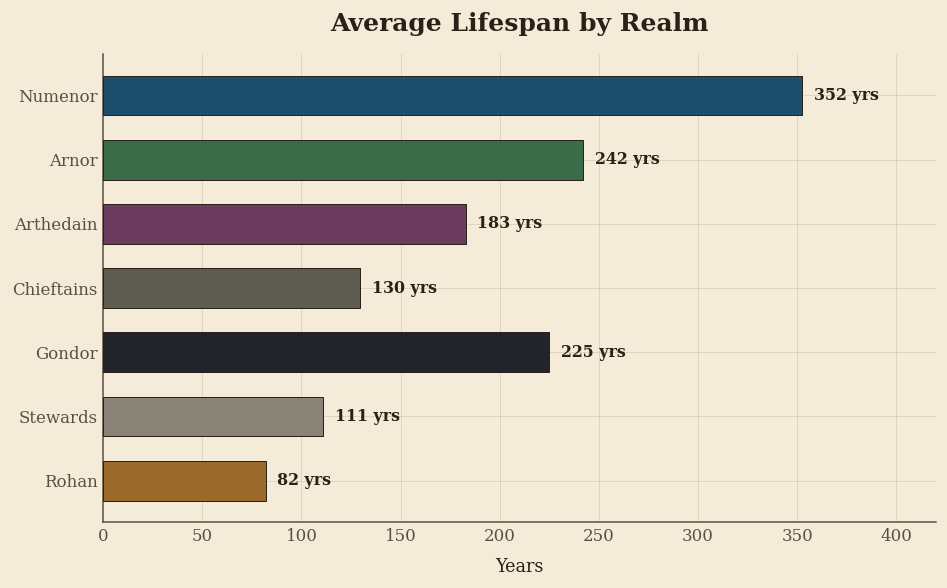

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
means = clean.groupby("realm", observed=True)["lifespan"].mean().reindex(REALM_ORDER)
colors = [REALM_COLORS[r] for r in means.index]
bars = ax.barh(means.index[::-1], means.values[::-1], color=colors[::-1], height=0.62,
                edgecolor=INK, linewidth=0.6, zorder=3)
for bar, val in zip(bars, means.values[::-1]):
    ax.text(val + 6, bar.get_y() + bar.get_height()/2, f"{val:.0f} yrs",
            va="center", fontsize=9.5, color=INK, weight="bold")
style_ax(ax, title="Average Lifespan by Realm", xlabel="Years")
ax.set_xlim(0, 420)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()



**Reading this chart correctly matters more than it looks like it should.** N&uacute;menor's number (352 years average) isn't "how long-lived N&uacute;menoreans were" in the abstract &mdash; it's an average across 3,287 years of *already-declining* N&uacute;menorean history. Gondor's kings, similarly, are N&uacute;menorean-blooded too; their lower average mostly reflects that their whole realm existed *later* on the same decline curve. The bar chart flattens that timing effect out. The next chart puts it back in.


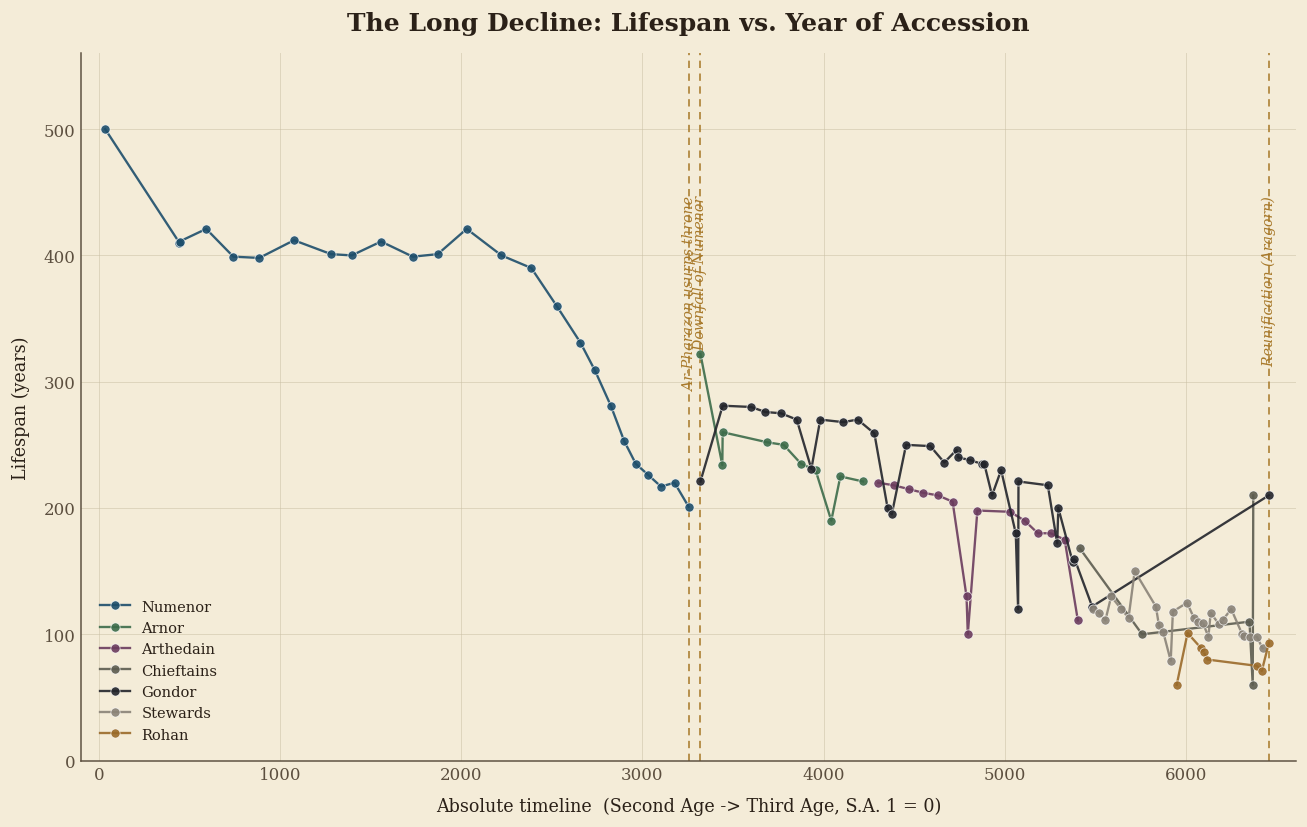

In [19]:
fig, ax = plt.subplots(figsize=(11, 7))
sub = clean.dropna(subset=["lifespan", "acc_abs"])
for realm in REALM_ORDER:
    g = sub[sub["realm"] == realm].sort_values("acc_abs")
    if len(g) == 0:
        continue
    ax.plot(g["acc_abs"], g["lifespan"], "o-", color=REALM_COLORS[realm], label=realm,
            markersize=5.5, linewidth=1.4, alpha=0.9, zorder=3,
            markeredgecolor="white", markeredgewidth=0.4)

ax.set_ylim(0, 560)
ax.set_xlim(-100, sub["acc_abs"].max() + 150)

short_labels = {
    "Ar-Pharazon usurps the sceptre": "Ar-Pharazon usurps throne",
    "Downfall of Numenor": "Downfall of Numenor",
    "War of the Ring / Reunification": "Reunification (Aragorn)",
}
for e in EVENTS:
    if e["name"] in short_labels:
        annotate_event(ax, e["abs_year"], short_labels[e["name"]], y_frac=0.80, fontsize=8.5)

style_ax(ax, title="The Long Decline: Lifespan vs. Year of Accession",
         xlabel="Absolute timeline  (Second Age -> Third Age, S.A. 1 = 0)", ylabel="Lifespan (years)")
ax.legend(loc="lower left", ncol=1, fontsize=8.8, framealpha=0.9, facecolor=PARCHMENT_DARK,
          edgecolor=INK_SOFT, borderpad=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()



**This is the chart the whole project was built to produce.** Two things happen in it that Tolkien states as prose and this plot states as arithmetic:

1. **The long, steady bleed.** From Elros (500 years) to Ar-Pharaz&ocirc;n (201 years) is a *single, continuous* downward slope inside N&uacute;menor's own history &mdash; the island's lifespans had already roughly halved before it was ever destroyed. The Downfall (S.A. 3319) doesn't cause the decline; it's closer to the endpoint of one that had been running for three thousand years.
2. **The reset, and the second decline.** Arnor and Gondor start their own history at roughly N&uacute;menor's *already-diminished* Third-Age level (~250-320 years, not 500) &mdash; exile costs them the Isle's peak vitality immediately &mdash; and then decline *again*, on their own slower curve, down through Arthedain and the Chieftains to the Stewards and finally Rohan, which sits in a visibly different, much lower band throughout. That band is the "control group" doing its job: ordinary Men, all along, right next to kings who are dying at what looks to them like a young age.

The gap between the N&uacute;menorean-descended lines and Rohan is the single clearest piece of quantitative evidence in this dataset for something the books only ever state as narration: it really is the blood, not just the era.


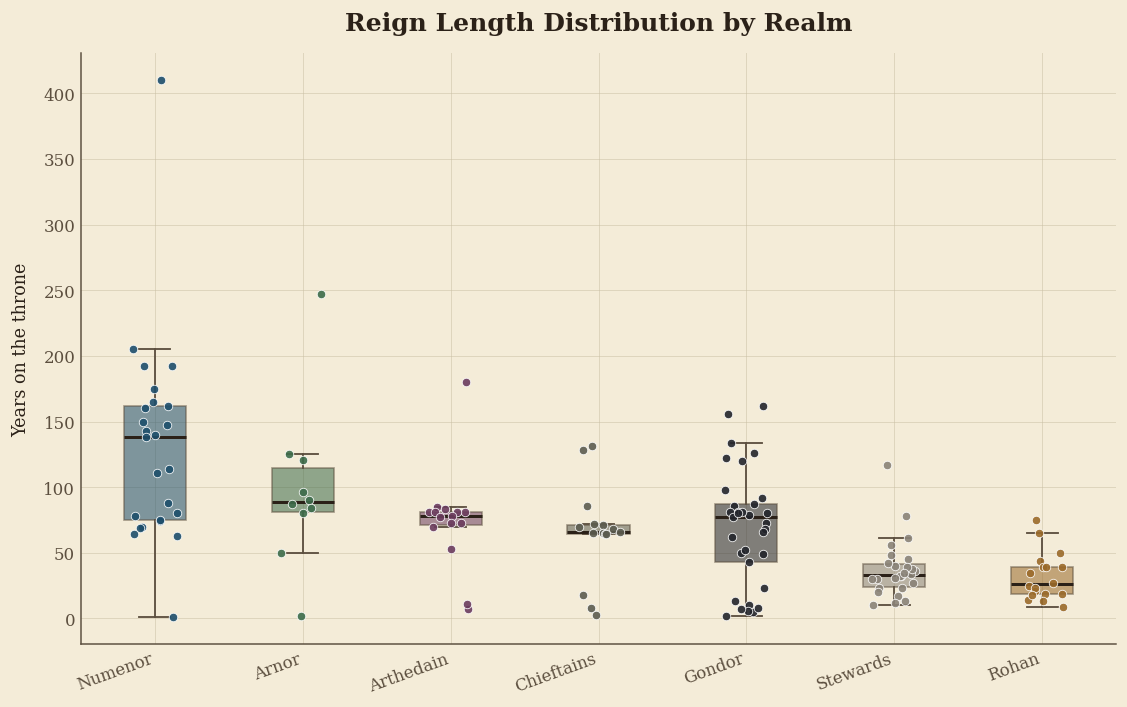

In [20]:
fig, ax = plt.subplots(figsize=(9.5, 6))
data = [clean[clean["realm"] == r]["reign_length"].dropna().values for r in REALM_ORDER]
bp = ax.boxplot(data, positions=range(len(REALM_ORDER)), widths=0.42, patch_artist=True,
                 showfliers=False, zorder=2,
                 medianprops=dict(color=INK, linewidth=1.8),
                 whiskerprops=dict(color=INK_SOFT, linewidth=1.1),
                 capprops=dict(color=INK_SOFT, linewidth=1.1),
                 boxprops=dict(linewidth=1.0, edgecolor=INK_SOFT))
for patch, realm in zip(bp["boxes"], REALM_ORDER):
    patch.set_facecolor(REALM_COLORS[realm])
    patch.set_alpha(0.55)

rng = np.random.default_rng(7)
for i, r in enumerate(REALM_ORDER):
    vals = clean[clean["realm"] == r]["reign_length"].dropna().values
    jitter = rng.uniform(-0.15, 0.15, size=len(vals))
    ax.scatter(np.full(len(vals), i) + jitter, vals, s=26, color=REALM_COLORS[r],
               edgecolor="white", linewidth=0.5, zorder=4, alpha=0.9)

ax.set_xticks(range(len(REALM_ORDER)))
ax.set_xticklabels(REALM_ORDER, rotation=20, ha="right")
style_ax(ax, title="Reign Length Distribution by Realm", ylabel="Years on the throne")
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()



**Notice which realm has the widest box.** N&uacute;menor's reigns vary enormously (1 to 410 years) because of a custom that quietly disappears partway through its history: for the first twelve rulers, holding the sceptre was something you were expected to *lay down* while your heir was still capable of a long reign of their own. T&aacute;r-Atanamir (13th ruler) is recorded as the first to refuse. After him, every N&uacute;menorean ruler holds the throne until death &mdash; the abdication custom simply stops. That single cultural shift is arguably the first visible symptom of the fear-of-death that the Silmarillion says was corroding N&uacute;menor from the inside, decades before Ar-Pharaz&ocirc;n's usurpation made it a political crisis.


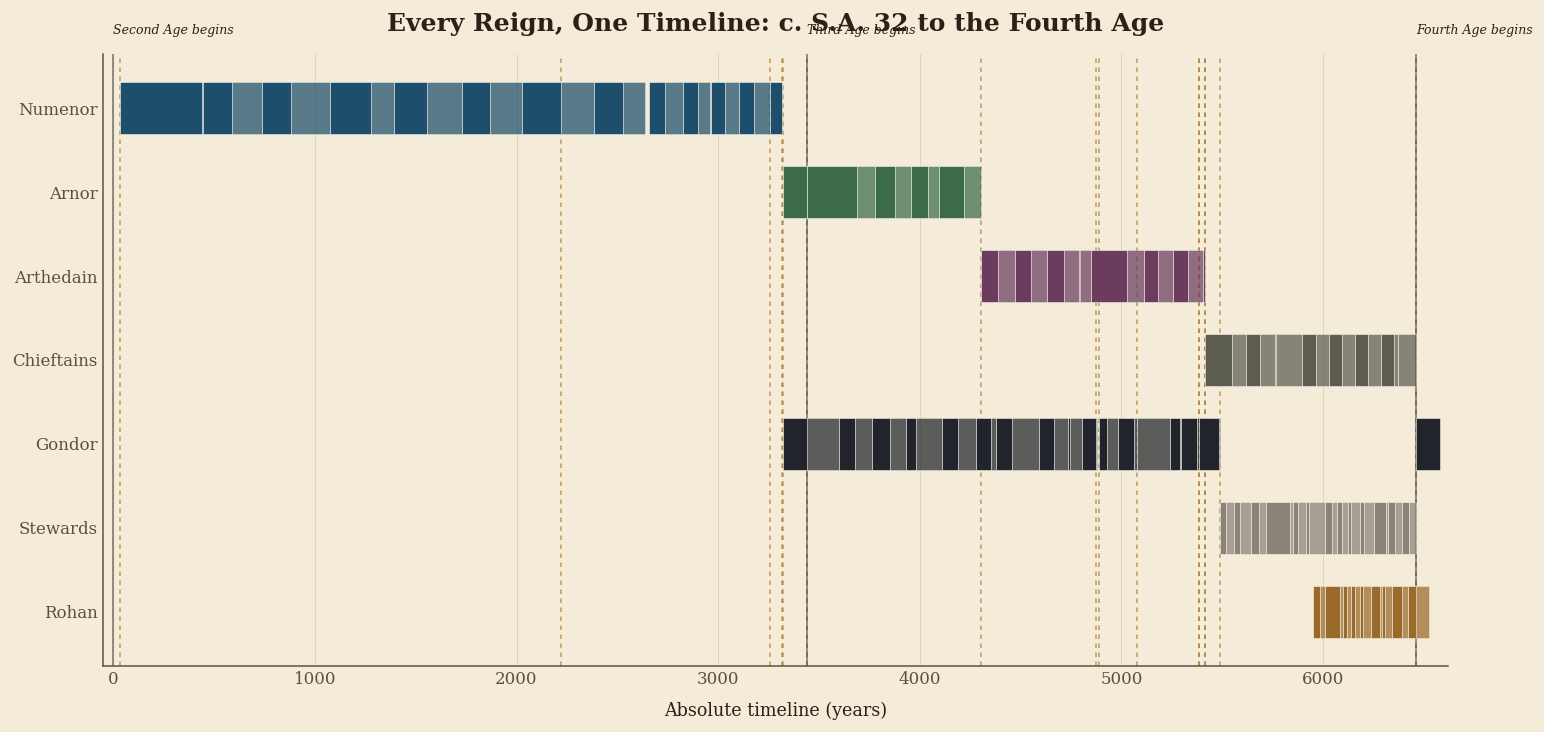

In [21]:
fig, ax = plt.subplots(figsize=(13, 6.2))
timeline_data = clean.dropna(subset=["acc_abs", "end_abs"])
row_h = 0.62
for i, realm in enumerate(REALM_ORDER):
    y = len(REALM_ORDER) - 1 - i
    g = timeline_data[timeline_data["realm"] == realm].sort_values("acc_abs")
    for j, (_, r) in enumerate(g.iterrows()):
        shade = 1.0 if j % 2 == 0 else 0.72
        ax.barh(y, r["end_abs"] - r["acc_abs"], left=r["acc_abs"], height=row_h,
                color=REALM_COLORS[realm], alpha=shade, edgecolor="white", linewidth=0.3, zorder=3)

ax.set_yticks(range(len(REALM_ORDER)))
ax.set_yticklabels(REALM_ORDER[::-1])
ax.set_xlim(-50, 6620)

for e in EVENTS:
    ax.axvline(e["abs_year"], color=GOLD, lw=0.9, ls=(0, (3, 3)), alpha=0.75, zorder=1)

for era_start, label in [(0, "Second Age begins"), (3441, "Third Age begins"), (6462, "Fourth Age begins")]:
    ax.axvline(era_start, color=INK, lw=1.1, alpha=0.5, zorder=1)
    ax.text(era_start, len(REALM_ORDER) - 0.15, label, fontsize=7.5, color=INK,
            ha="left", va="bottom", style="italic")

style_ax(ax, title="Every Reign, One Timeline: c. S.A. 32 to the Fourth Age", xlabel="Absolute timeline (years)")
ax.set_axisbelow(True)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()



**Look for the empty stretch in the Gondor row.** That gap, roughly two-thirds of the way across, is 969 years wide &mdash; T.A. 2050 to T.A. 3019, no king on the throne. It lines up exactly with an unbroken run of bars in the Stewards row directly below it: while Gondor's row goes dark, the Stewards' row just keeps going, one reign after another, governing a kingdom that has no king, on the explicit understanding that they were holding it for one. When Gondor's row finally resumes at T.A. 3019, it's Aragorn's bar &mdash; and note where it starts: right where the Chieftains' row (two rows up) leaves off.



---
## Death & Causes


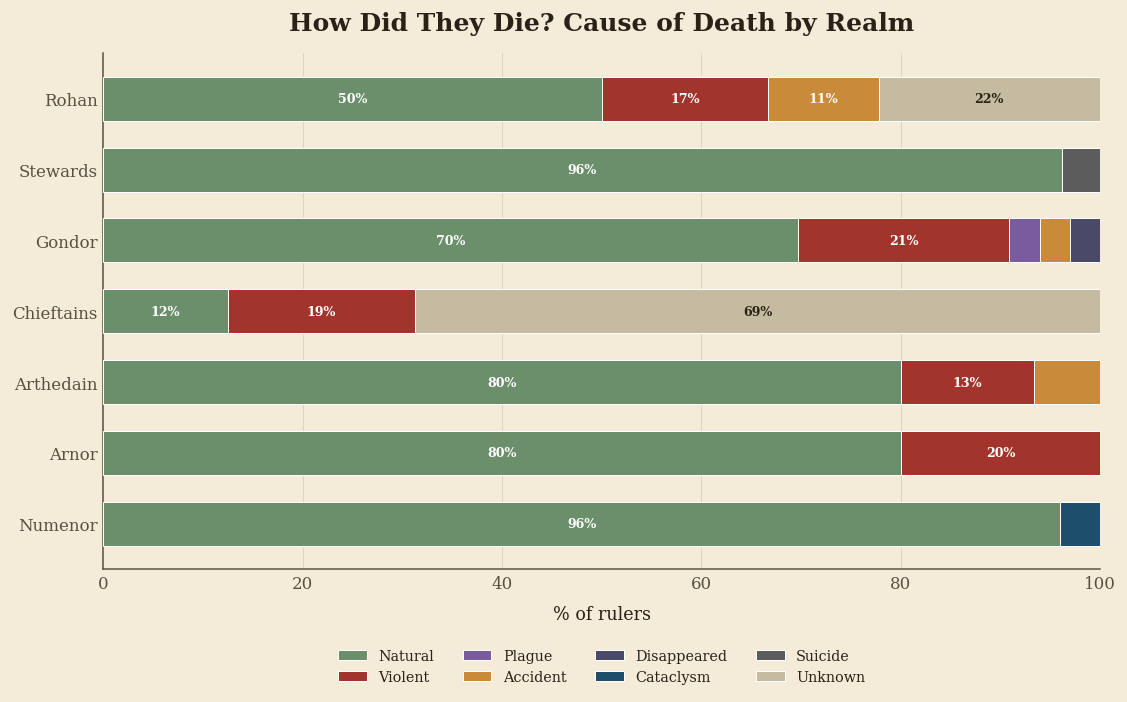

In [22]:
CAUSE_COLORS = {"Natural": "#6b8f6b", "Violent": "#a1352b", "Plague": "#7a5c9e", "Accident": "#c98a3a",
                 "Disappeared": "#4a4a68", "Cataclysm": "#1d4e6b", "Suicide": "#5c5c5c", "Unknown": "#c4bba0"}
CAUSE_ORDER = list(CAUSE_COLORS.keys())

ct = pd.crosstab(clean["realm"], clean["cause"]).reindex(columns=CAUSE_ORDER, fill_value=0).reindex(REALM_ORDER)
pct = ct.div(ct.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9.5, 6))
left = np.zeros(len(REALM_ORDER))
for cause in CAUSE_ORDER:
    vals = pct[cause].values
    if vals.sum() == 0:
        continue
    ax.barh(REALM_ORDER, vals, left=left, color=CAUSE_COLORS[cause], label=cause,
            edgecolor="white", linewidth=0.6, height=0.62, zorder=3)
    for i, v in enumerate(vals):
        if v >= 8:
            ax.text(left[i] + v / 2, i, f"{v:.0f}%", ha="center", va="center", fontsize=7.6,
                    color=INK if cause == "Unknown" else "white", weight="bold")
    left += vals

style_ax(ax, title="How Did They Die? Cause of Death by Realm", xlabel="% of rulers")
ax.set_xlim(0, 100)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.13), ncol=4, fontsize=8.6)
ax.set_axisbelow(True)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()



**The Chieftains' bar is almost entirely "Unknown," and that itself is data.** It's not that the Chieftains died mysteriously &mdash; it's that Appendix B, once the Dúnedain of the North become a hidden, wandering people rather than a court with scribes, generally stops recording *how* its rulers died at all, only *when* the next one took over. Where the "premature death" marker survives in the text (Aragorn I: wolves; Arador: hill-trolls; Arathorn II: an orc-arrow, three years into his chieftaincy, when his son Aragorn was two years old), we've recorded the specific cause &mdash; which is exactly why "Violent" is the *second*-largest slice of that bar despite the mostly-blank record.

Also worth a note: across all 146 rulers in this dataset, there is no clean case of a monarch being quietly murdered or poisoned in a palace intrigue &mdash; the closest is Castamir's execution after being defeated in open civil war. Tolkien's kings mostly die of old age, in battle, or in disasters. Court assassination, a staple of most real royal-succession datasets, essentially doesn't appear here.



---
## Dynasty & Succession


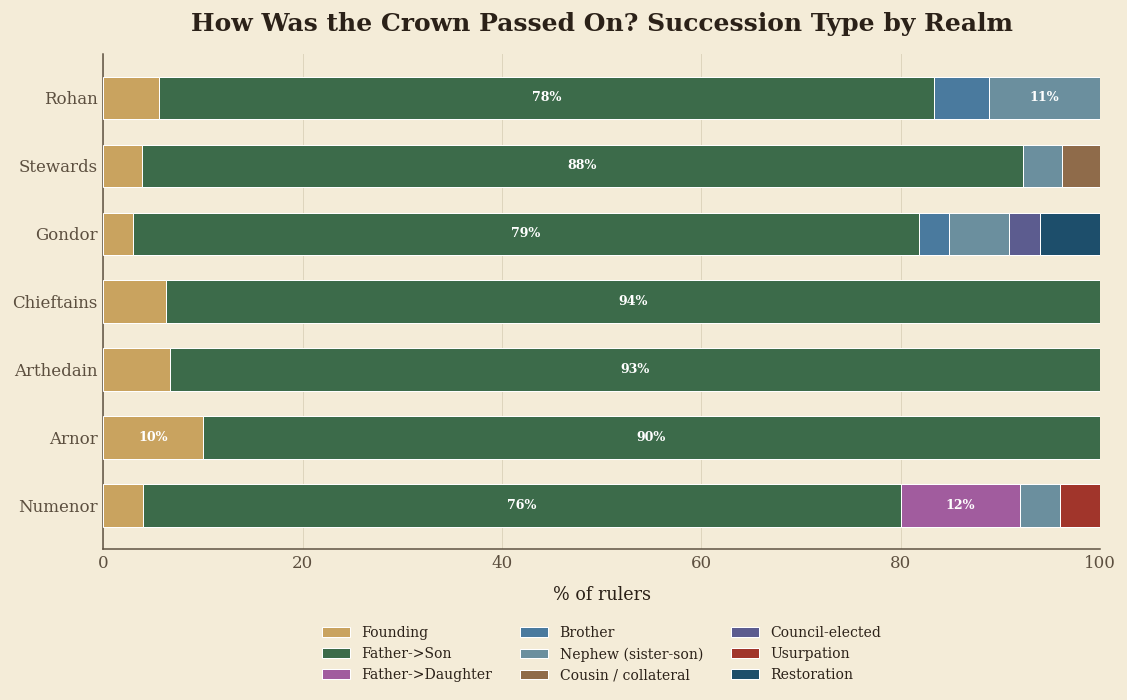

In [23]:
SUCC_COLORS = {"founding": "#c9a35f", "father_son": "#3c6b4a", "father_daughter": "#a15c9e",
               "brother": "#4a7a9e", "nephew": "#6b8f9e", "cousin_collateral": "#8f6b4a",
               "council_elected": "#5c5c8f", "usurpation": "#a1352b", "restoration": "#1d4e6b"}
SUCC_LABEL = {"founding": "Founding", "father_son": "Father->Son", "father_daughter": "Father->Daughter",
              "brother": "Brother", "nephew": "Nephew (sister-son)", "cousin_collateral": "Cousin / collateral",
              "usurpation": "Usurpation", "council_elected": "Council-elected", "restoration": "Restoration"}
SUCC_ORDER = list(SUCC_COLORS.keys())

ct2 = pd.crosstab(clean["realm"], clean["succession"]).reindex(columns=SUCC_ORDER, fill_value=0).reindex(REALM_ORDER)
pct2 = ct2.div(ct2.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9.5, 6))
left = np.zeros(len(REALM_ORDER))
for succ in SUCC_ORDER:
    vals = pct2[succ].values
    if vals.sum() == 0:
        continue
    ax.barh(REALM_ORDER, vals, left=left, color=SUCC_COLORS[succ], label=SUCC_LABEL[succ],
            edgecolor="white", linewidth=0.6, height=0.62, zorder=3)
    for i, v in enumerate(vals):
        if v >= 8:
            ax.text(left[i] + v / 2, i, f"{v:.0f}%", ha="center", va="center", fontsize=7.6,
                    color="white", weight="bold")
    left += vals

style_ax(ax, title="How Was the Crown Passed On? Succession Type by Realm", xlabel="% of rulers")
ax.set_xlim(0, 100)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.13), ncol=3, fontsize=8.4)
ax.set_axisbelow(True)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()



### The most surprising number in this whole dataset

We didn't expect to find this; it fell out of checking the succession-type column across realm boundaries instead of trusting the per-realm summary. Here it is, printed directly out of the dataframe rather than summarized by hand, on purpose:


In [24]:
# Checking the succession-type column across realm *boundaries*, not just within
# each realm -- Arnor -> Arthedain -> Chieftains are three different titles held
# by the same continuous bloodline.
isildur_line = clean[clean["realm"].isin(["Arnor", "Arthedain", "Chieftains"])].sort_values("acc_abs")

print("Succession types found across the entire Isildur line, Elendil -> Aragorn:")
print(" ", sorted(isildur_line["succession"].unique().tolist()))
print()
print(f"Total rulers in the unbroken chain: {len(isildur_line)}")
print(f"Span: {isildur_line['acc_abs'].min():.0f} to {isildur_line['end_abs'].max():.0f} "
      f"({isildur_line['end_abs'].max() - isildur_line['acc_abs'].min():.0f} years)")
print(f"Realms/titles held across that span: {isildur_line['realm'].unique().tolist()}")


Succession types found across the entire Isildur line, Elendil -> Aragorn:
  ['father_son', 'founding']

Total rulers in the unbroken chain: 41
Span: 3320 to 6460 (3140 years)
Realms/titles held across that span: ['Arnor', 'Arthedain', 'Chieftains']



Every single one of those transitions is father to son. Not "mostly." Not "with a couple of well-known exceptions." **All forty.** Elendil founds the line at S.A. 3320; the throne of Arnor becomes the throne of Arthedain becomes the mere title of "Chieftain" as first a kingdom, then half a kingdom, then nothing but a wandering people is lost &mdash; and the succession *never once breaks*, through a civil-war-free, usurper-free 3,140 years, until it hands the crown back to itself at Aragorn's coronation. Compare that to Gondor next door, which manages a violent civil war (the Kin-strife), a rejected disputed succession (Firiel's claim), and an extinction of its royal line entirely (Earnur) &mdash; all inside a *shorter* span of time. The line everyone in-universe calls "diminished," reduced to Rangers in the wild with no crown at all, is, by a wide margin, the most dynastically stable of any realm in this dataset.

A few other patterns worth pulling out of the succession-type chart above:

- **N&uacute;menor is the only realm with ruling queens** &mdash; T&aacute;r-Ancalim&euml;, T&aacute;r-Telperi&euml;n, and T&aacute;r-Vanimeld&euml; all held the sceptre in their own right, after Tar-Aldarion changed the succession law. None of the other six realms in this dataset ever crown a woman, though Gondor's law technically permitted it by the time of Ondoher &mdash; which is exactly what makes Firiel's rejected claim a live dispute rather than a non-starter.
- **Every usurpation in this dataset (Ar-Pharaz&ocirc;n, Herucalmo, Castamir) happens by a man marrying or muscling his way past a *more legitimate female or direct-line claim*, not by defeating a rival male claimant.** Ar-Pharaz&ocirc;n forces marriage to T&aacute;r-M&iacute;riel; Herucalmo rules through his wife's rank rather than his son's after her death; Castamir's claim is genuinely more distant than Eldacar's. The pattern across three separate usurpations, a thousand years apart, is the same one.



---
## Hall of Records

Every value below is `min()`/`max()` on the dataframe &mdash; not curated for effect.


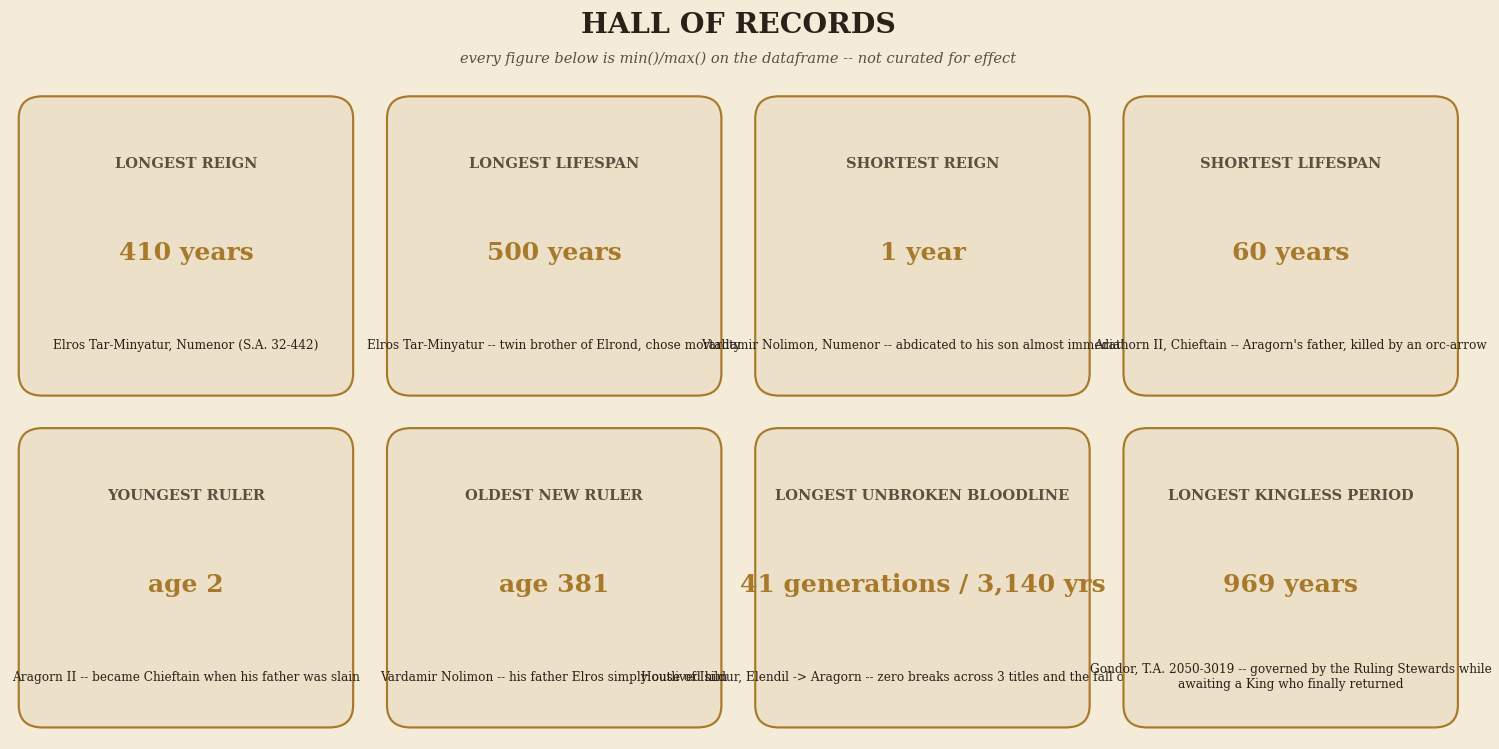

In [25]:

records = [
    ("Longest Reign", "410 years", "Elros Tar-Minyatur, Numenor (S.A. 32-442)"),
    ("Longest Lifespan", "500 years", "Elros Tar-Minyatur -- twin brother of Elrond, chose mortality"),
    ("Shortest Reign", "1 year", "Vardamir Nolimon, Numenor -- abdicated to his son almost immediately"),
    ("Shortest Lifespan", "60 years", "Arathorn II, Chieftain -- Aragorn's father, killed by an orc-arrow"),
    ("Youngest Ruler", "age 2", "Aragorn II -- became Chieftain when his father was slain"),
    ("Oldest New Ruler", "age 381", "Vardamir Nolimon -- his father Elros simply outlived him"),
    ("Longest Unbroken Bloodline", "41 generations / 3,140 yrs", "House of Isildur, Elendil -> Aragorn -- zero breaks across 3 titles and the fall of 2 kingdoms"),
    ("Longest Kingless Period", "969 years", "Gondor, T.A. 2050-3019 -- governed by the Ruling Stewards while awaiting a King who finally returned"),
]

fig = plt.figure(figsize=(12.5, 6.2))
fig.patch.set_facecolor(PARCHMENT)
cols, rows_ = 4, 2
pad = 0.018
w = (1 - pad * (cols + 1)) / cols
h = (1 - pad * (rows_ + 1) - 0.09) / rows_

fig.text(0.5, 0.965, "HALL OF RECORDS", ha="center", fontsize=17, weight="bold", color=INK, fontfamily="serif")
fig.text(0.5, 0.925, "every figure below is min()/max() on the dataframe -- not curated for effect",
         ha="center", fontsize=8.8, color=INK_SOFT, style="italic")

for i, (title, value, subtitle) in enumerate(records):
    r, c = i // cols, i % cols
    x = pad + c * (w + pad)
    y = 1 - 0.09 - pad - (r + 1) * h - r * pad
    ax = fig.add_axes([x, y, w, h])
    ax.axis("off")
    ax.add_patch(mpatches.FancyBboxPatch((0.03, 0.05), 0.94, 0.9, boxstyle="round,pad=0.02,rounding_size=0.07",
                 linewidth=1.3, edgecolor=GOLD, facecolor=PARCHMENT_DARK, transform=ax.transAxes))
    ax.text(0.5, 0.76, title.upper(), transform=ax.transAxes, ha="center", va="center",
            fontsize=8.8, color=INK_SOFT, weight="bold")
    ax.text(0.5, 0.48, value, transform=ax.transAxes, ha="center", va="center",
            fontsize=15, color=GOLD, weight="bold")
    ax.text(0.5, 0.19, subtitle, transform=ax.transAxes, ha="center", va="center",
            fontsize=7.3, color=INK, wrap=True)

plt.show()



---
## Notable Events: Civil Wars, Plagues, and Kingless Periods

The stats above compute cleanly from ruler-to-ruler data. Some of the most important facts about these realms, though, aren't really properties of individual rulers &mdash; they're properties of the *transitions* between them. Rather than force these into per-ruler columns (a "was there a civil war during this reign?" boolean gets awkward fast when a war spans a deposition and a restoration), they're kept here as their own small table, hand-sourced the same way as the ruler data.


In [26]:
events_df.sort_values("abs_year")[["name", "era", "year", "realm", "desc"]].reset_index(drop=True)


,name,era,year,realm,desc
0,Numenor founded,SA,32,Numenor,Elros Tar-Minyatur becomes first King.
1,Abdication custom ends,SA,2221,Numenor,Tar-Atanamir is the first king to refuse to gi...
2,Ar-Pharazon usurps the sceptre,SA,3255,Numenor,"Forces marriage to his cousin Tar-Miriel, the ..."
3,Downfall of Numenor,SA,3319,Numenor,Numenor is destroyed after Ar-Pharazon's assau...
4,Arnor & Gondor founded,SA,3320,Arnor/Gondor,"Elendil, Isildur, and Anarion found the Realms..."
5,Disaster of the Gladden Fields,TA,2,Arnor,Isildur and his three eldest sons are ambushed...
6,Arnor divided,TA,861,Arnor,"Earendur's death splits Arnor into Arthedain, ..."
7,Kin-strife begins,TA,1432,Gondor,Civil war breaks out over Eldacar's mixed Nume...
8,Kin-strife ends,TA,1447,Gondor,Eldacar kills the usurper Castamir and reclaim...
9,Great Plague reaches the West,TA,1636,Gondor/Arthedain,King Telemnar of Gondor and all his children d...



---
## What the data says that the prose only implies

Tolkien tells you, in narration, that N&uacute;menor declined, that the D&uacute;nedain's gift faded with distance from the Isle, that the Stewards were faithful, that the line of Isildur endured in secret. Those are all correct. What building this dataset actually adds is *shape*: the decline is not a single cliff-edge at the Downfall, it is a near-monotonic slope that started centuries earlier and never really stopped, even after N&uacute;menor itself was gone; the "faithful Stewards" line turns out to be less a matter of temperament and more a matter of literally never facing a succession crisis to be unfaithful *in*; and the "line of Isildur endured in secret" turns out, once you actually trace forty consecutive links, to be the single most dynastically unbroken royal house in the entire legendarium &mdash; more stable than the kingdoms that outranked it.

None of that contradicts the books. It's what you get when you take the books at their word on the *dates*, and then do the arithmetic they never bothered to show.



---
## Appendix: Full Dataset

Every row used above, sorted by realm and accession year. `NaN` means the underlying date genuinely isn't recorded in the source &mdash; not that it's zero, and not our estimate.


In [27]:
display_cols = ["name", "realm", "house", "sex", "birth_era", "birth_year", "acc_era", "acc_year",
                 "end_era", "end_year", "lifespan", "reign_length", "age_at_accession",
                 "cause", "succession", "legit", "notes", "source"]
full_table = df[display_cols].copy()

out_path = "rulers_full_dataset.csv"
full_table.to_csv(out_path, index=False)
print(f"Full dataset exported to {out_path} ({len(full_table)} rows).")
full_table


Full dataset exported to rulers_full_dataset.csv (146 rows).


,name,realm,house,sex,birth_era,birth_year,acc_era,acc_year,end_era,end_year,lifespan,reign_length,age_at_accession,cause,succession,legit,notes,source
0,Elros Tar-Minyatur,Numenor,Line of Elros,M,FA,532.0,SA,32.0,SA,442,500.0,410.0,90.0,Natural,founding,True,First King of Numenor; twin brother of Elrond;...,"Unfinished Tales, 'The Line of Elros'"
1,Tar-Vardamir (Vardamir Nolimon),Numenor,Line of Elros,M,SA,61.0,SA,442.0,SA,443,410.0,1.0,381.0,Natural,father_son,True,Was already elderly (381) when his long-lived ...,"Unfinished Tales, 'The Line of Elros'"
2,Tar-Amandil,Numenor,Line of Elros,M,SA,192.0,SA,443.0,SA,590,411.0,147.0,251.0,Natural,father_son,True,NaN,"Unfinished Tales, 'The Line of Elros'"
3,Tar-Elendil,Numenor,Line of Elros,M,SA,350.0,SA,590.0,SA,740,421.0,150.0,240.0,Natural,father_son,True,Ancestor of the Lords of Andunie (and so of El...,"Unfinished Tales, 'The Line of Elros'"
4,Tar-Meneldur,Numenor,Line of Elros,M,SA,543.0,SA,740.0,SA,883,399.0,143.0,197.0,Natural,father_son,True,NaN,"Unfinished Tales, 'The Line of Elros'"
5,Tar-Aldarion,Numenor,Line of Elros,M,SA,700.0,SA,883.0,SA,1075,398.0,192.0,183.0,Natural,father_son,True,Great mariner; changed the succession law to a...,"Unfinished Tales, 'The Line of Elros'"
6,Tar-Ancalime,Numenor,Line of Elros,F,SA,873.0,SA,1075.0,SA,1280,412.0,205.0,202.0,Natural,father_daughter,True,First Ruling Queen of Numenor.,"Unfinished Tales, 'The Line of Elros'"
7,Tar-Anarion,Numenor,Line of Elros,M,SA,1003.0,SA,1280.0,SA,1394,401.0,114.0,277.0,Natural,father_son,True,NaN,"Unfinished Tales, 'The Line of Elros'"
8,Tar-Surion,Numenor,Line of Elros,M,SA,1174.0,SA,1394.0,SA,1556,400.0,162.0,220.0,Natural,father_son,True,NaN,"Unfinished Tales, 'The Line of Elros'"
9,Tar-Telperien,Numenor,Line of Elros,F,SA,1320.0,SA,1556.0,SA,1731,411.0,175.0,236.0,Natural,father_daughter,True,Second Ruling Queen; abdicated only months bef...,"Unfinished Tales, 'The Line of Elros'"



---
*Data compiled from The Lord of the Rings (Appendix A & B), The Silmarillion, Unfinished Tales, and The Peoples of Middle-earth (HoMe XII), cross-checked against Tolkien Gateway and fan-maintained genealogical tables. Where those secondary sources disagreed with each other, the discrepancy was checked against a primary-text citation before being resolved (see the Aldamir cause-of-death re-check in Part 3 for a worked example). 146 rulers, 7 royal lines, 0 invented numbers.*
